In [44]:
import pandas as pd
import numpy as np
import calendar
hydro_stations = [
    'Guide',
    'Xunhua'
]
import HydroErr as he
from metrics import PPMAE,LPMAE

In [45]:
start_date = '1961-01-01'
end_date = '1985-12-31'
for hydro_station in hydro_stations:
    # Read data files
    CER_XGB = pd.read_csv(f'../results/vif_xgb_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_LSTM = pd.read_csv(f'../results/vif_lstm_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_BiLSTM = pd.read_csv(f'../results/vif_bilstm_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_CNN = pd.read_csv(f'../results/vif_cnn_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_MLR = pd.read_csv(f'../results/vif_mlr_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()

    E_XGB = pd.read_csv(f'../results/xgb(Extension)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    E_LSTM = pd.read_csv(f'../results/lstm(Extension)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    E_BiLSTM = pd.read_csv(f'../results/bilstm(Extension)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    E_CNN = pd.read_csv(f'../results/cnn(Extension)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    E_MLR = pd.read_csv(f'../results/mlr(Extension)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()

    R_XGB = pd.read_csv(f'../results/xgb(Routing)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    R_LSTM = pd.read_csv(f'../results/lstm(Routing)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    R_BiLSTM = pd.read_csv(f'../results/bilstm(Routing)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    R_CNN = pd.read_csv(f'../results/cnn(Routing)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    R_MLR = pd.read_csv(f'../results/mlr(Routing)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()

    # Get observed flow data
    obs_flow = CER_BiLSTM.loc[start_date:end_date,['flow']]
    
    # Get calibration/validation data for each model
    CER_XGB_calval = CER_XGB.loc[start_date:end_date,['CER-XGB']]
    CER_LSTM_calval = CER_LSTM.loc[start_date:end_date,['CER-LSTM']]
    CER_BiLSTM_calval = CER_BiLSTM.loc[start_date:end_date,['CER-BiLSTM']]
    CER_CNN_calval = CER_CNN.loc[start_date:end_date,['CER-CNN']]
    CER_MLR_calval = CER_MLR.loc[start_date:end_date,['CER-MLR']]

    E_XGB_calval = E_XGB.loc[start_date:end_date,['E-XGB']]
    E_LSTM_calval = E_LSTM.loc[start_date:end_date,['E-LSTM']]
    E_BiLSTM_calval = E_BiLSTM.loc[start_date:end_date,['E-BiLSTM']]
    E_CNN_calval = E_CNN.loc[start_date:end_date,['E-CNN']]
    E_MLR_calval = E_MLR.loc[start_date:end_date,['E-MLR']]

    R_XGB_calval = R_XGB.loc[start_date:end_date,['R-XGB']]
    R_LSTM_calval = R_LSTM.loc[start_date:end_date,['R-LSTM']]
    R_BiLSTM_calval = R_BiLSTM.loc[start_date:end_date,['R-BiLSTM']]
    R_CNN_calval = R_CNN.loc[start_date:end_date,['R-CNN']]
    R_MLR_calval = R_MLR.loc[start_date:end_date,['R-MLR']]
    

    # Create scatter plots for each model
    import matplotlib.pyplot as plt
    
    # CER models
    fig, axes = plt.subplots(3, 5, figsize=(7.48, 6.5))  # Adjusted figure size for square subplots
    # fig.suptitle(f'Simulated vs Observed Flow at {hydro_station} Station', fontsize=8)
    
    # Plot CER models
    models = {
        'CER-XGB': CER_XGB_calval,
        'CER-LSTM': CER_LSTM_calval,
        'CER-BiLSTM': CER_BiLSTM_calval,
        'CER-CNN': CER_CNN_calval,
        'CER-MLR': CER_MLR_calval,
        'E-XGB': E_XGB_calval,
        'E-LSTM': E_LSTM_calval,
        'E-BiLSTM': E_BiLSTM_calval,
        'E-CNN': E_CNN_calval,
        'E-MLR': E_MLR_calval,
        'R-XGB': R_XGB_calval,
        'R-LSTM': R_LSTM_calval,
        'R-BiLSTM': R_BiLSTM_calval,
        'R-CNN': R_CNN_calval,
        'R-MLR': R_MLR_calval
    }
    
    for idx, (model_name, model_data) in enumerate(models.items()):
        row = idx // 5
        col = idx % 5
        ax = axes[row, col]

        print(model_name,obs_flow.shape[0],model_data.shape[0])
        
        # Plot scatter points
        ax.scatter(obs_flow, model_data, alpha=0.5)
        
        # Add linear fit line
        z = np.polyfit(obs_flow.values.flatten(), model_data.values.flatten(), 1)
        p = np.poly1d(z)
        x_range = np.linspace(0, obs_flow.max().max(), 100)
        ax.plot(x_range, p(x_range), 'k-', label='Linear fit')
        
        # Add 1:1 line
        max_val = max(obs_flow.max().max(), model_data.max().max())
        ax.plot([0, max_val], [0, max_val], 'r--', label='Ideal fit')
        
        # Customize plot
        ax.set_xlabel('Observed($m^3/s$)', fontsize=8)
        # Only show ylabel for first column
        if col == 0:
            ax.set_ylabel('Simulated($m^3/s$)', fontsize=8)
        else:
            ax.set_ylabel('')
        ax.set_title(model_name, fontsize=8)
        ax.grid(True)
        
        # Set scientific notation only for y-axis with font size 6
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax.yaxis.get_offset_text().set_fontsize(6)
        
        # Set tick label font size
        ax.tick_params(axis='both', which='major', labelsize=6)
        
        # Make subplot square
        ax.set_aspect('equal')
        
        # Add legend only for the last plot (CER(MLR))
        if model_name == 'CER-BiLSTM':
            ax.legend(fontsize=6,ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.45), frameon=False)
        
    plt.subplots_adjust(wspace=0.2, hspace=0.1)
    plt.savefig(f'../figs/calval_scatter_plots_{hydro_station.lower()}.tif', dpi=500, bbox_inches='tight')
    plt.close()
    plt.show()


CER-XGB 300 300
CER-LSTM 300 300
CER-BiLSTM 300 300
CER-CNN 300 300
CER-MLR 300 300
E-XGB 300 300
E-LSTM 300 300
E-BiLSTM 300 300
E-CNN 300 300
E-MLR 300 300
R-XGB 300 300
R-LSTM 300 300
R-BiLSTM 300 300
R-CNN 300 300
R-MLR 300 300
CER-XGB 300 300
CER-LSTM 300 300
CER-BiLSTM 300 300
CER-CNN 300 300
CER-MLR 300 300
E-XGB 300 300
E-LSTM 300 300
E-BiLSTM 300 300
E-CNN 300 300
E-MLR 300 300
R-XGB 300 300
R-LSTM 300 300
R-BiLSTM 300 300
R-CNN 300 300
R-MLR 300 300


c:\Users\ZJY\miniconda3\envs\pytorch\Lib\site-packages\HydroErr\HydroErr.py:346: RuntimeWarning: invalid value encountered in log1p
  sim_log = np.log1p(simulated_array)
c:\Users\ZJY\miniconda3\envs\pytorch\Lib\site-packages\HydroErr\HydroErr.py:426: RuntimeWarning: invalid value encountered in log1p
  sim_log = np.log1p(simulated_array)
c:\Users\ZJY\miniconda3\envs\pytorch\Lib\site-packages\HydroErr\HydroErr.py:506: RuntimeWarning: invalid value encountered in log1p
  sim_log = np.log1p(simulated_array)
c:\Users\ZJY\miniconda3\envs\pytorch\Lib\site-packages\HydroErr\HydroErr.py:1041: RuntimeWarning: invalid value encountered in log1p
  return np.sqrt(np.mean(np.power(np.log1p(simulated_array) - np.log1p(observed_array), 2)))
c:\Users\ZJY\miniconda3\envs\pytorch\Lib\site-packages\HydroErr\HydroErr.py:3769: RuntimeWarning: invalid value encountered in log10
  second2 = np.log10(simulated_array) - np.log10(np.mean(simulated_array))
c:\Users\ZJY\miniconda3\envs\pytorch\Lib\site-packages\H


Top 10 metrics with highest variance across models:
MSE      2.016172e+06
ED       5.861016e+04
MDSE     4.111276e+04
PPMAE    7.072856e+02
RMSE     1.953672e+02
ME       1.345729e+02
MDE      1.132285e+02
MAE      1.064450e+02
MDAE     5.897406e+01
LPMAE    3.617561e+01
dtype: float64
['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']


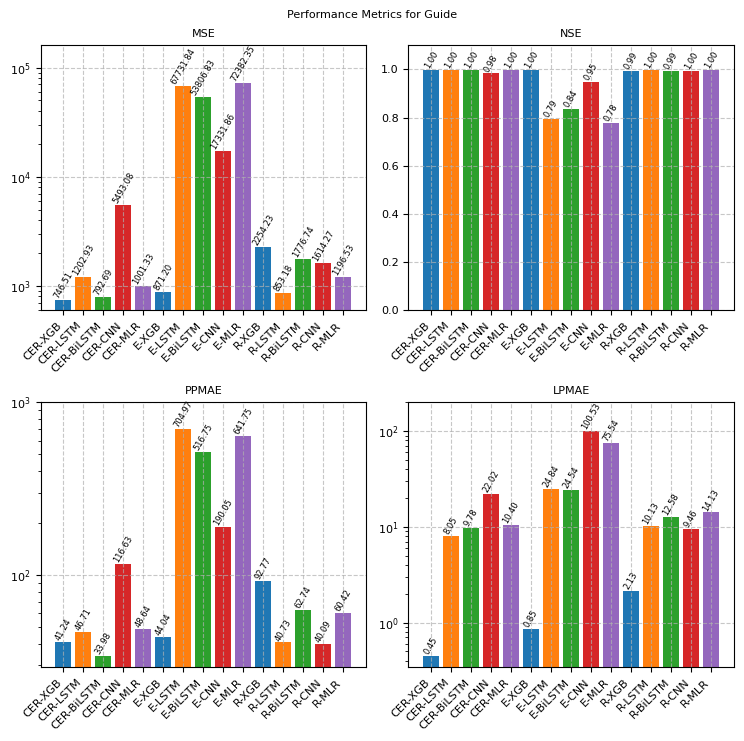


Top 10 metrics with highest variance across models:
MSE      815544.665671
MDSE      99574.728856
ED        22010.837293
ME          292.133148
PPMAE       245.725724
MDE         217.769071
MAE         140.715587
MDAE         95.543328
LPMAE        74.191975
RMSE         73.369458
dtype: float64
['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']


C:\Users\ZJY\AppData\Local\Temp\ipykernel_144212\1774124278.py:290: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[idx].set_ylim(y_limits[metric])
C:\Users\ZJY\AppData\Local\Temp\ipykernel_144212\1774124278.py:290: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[idx].set_ylim(y_limits[metric])
C:\Users\ZJY\AppData\Local\Temp\ipykernel_144212\1774124278.py:290: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[idx].set_ylim(y_limits[metric])


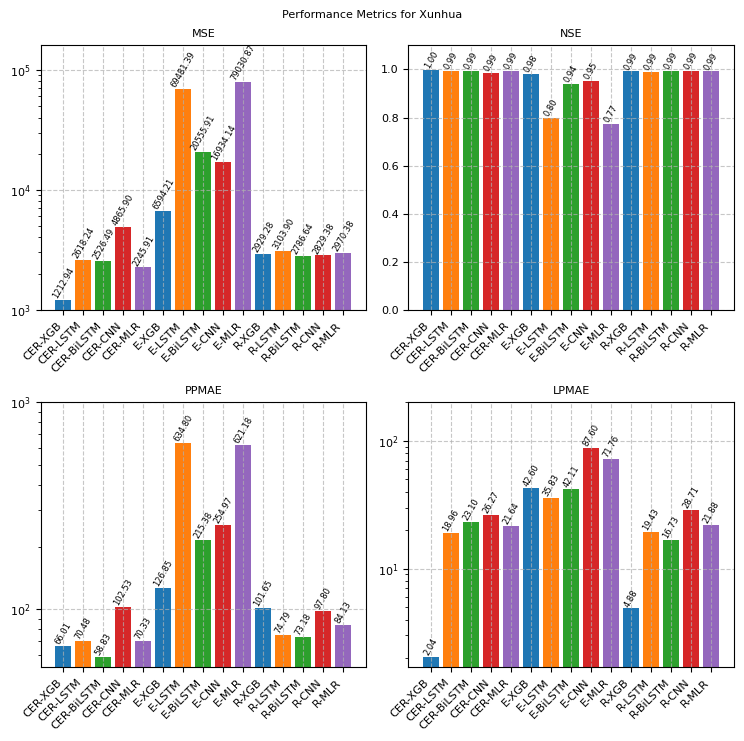

CER MSE 0.7
CER PPMAE 0.7
CER LPMAE 0.8


In [63]:
start_date = '1961-01-01'
end_date = '1985-12-31'
CER_BETTER_MSE = []
CER_BETTER_PPMAE = []
CER_BETTER_LPMAE = []
for hydro_station in hydro_stations:
    # Read data files
    CER_XGB = pd.read_csv(f'../results/vif_xgb_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_LSTM = pd.read_csv(f'../results/vif_lstm_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_BiLSTM = pd.read_csv(f'../results/vif_bilstm_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_CNN = pd.read_csv(f'../results/vif_cnn_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_MLR = pd.read_csv(f'../results/vif_mlr_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()

    E_XGB = pd.read_csv(f'../results/xgb(Extension)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    E_LSTM = pd.read_csv(f'../results/lstm(Extension)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    E_BiLSTM = pd.read_csv(f'../results/bilstm(Extension)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    E_CNN = pd.read_csv(f'../results/cnn(Extension)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    E_MLR = pd.read_csv(f'../results/mlr(Extension)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()

    R_XGB = pd.read_csv(f'../results/xgb(Routing)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    R_LSTM = pd.read_csv(f'../results/lstm(Routing)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    R_BiLSTM = pd.read_csv(f'../results/bilstm(Routing)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    R_CNN = pd.read_csv(f'../results/cnn(Routing)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    R_MLR = pd.read_csv(f'../results/mlr(Routing)_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()

    # Get observed flow data
    obs_flow = CER_BiLSTM.loc[start_date:end_date,['flow']].values.flatten()
    
    # Get calibration/validation data for each model
    CER_XGB_calval = CER_XGB.loc[start_date:end_date,['CER-XGB']].values.flatten()
    CER_LSTM_calval = CER_LSTM.loc[start_date:end_date,['CER-LSTM']].values.flatten()
    CER_BiLSTM_calval = CER_BiLSTM.loc[start_date:end_date,['CER-BiLSTM']].values.flatten()
    CER_CNN_calval = CER_CNN.loc[start_date:end_date,['CER-CNN']].values.flatten()
    CER_MLR_calval = CER_MLR.loc[start_date:end_date,['CER-MLR']].values.flatten()

    E_XGB_calval = E_XGB.loc[start_date:end_date,['E-XGB']].values.flatten()
    E_LSTM_calval = E_LSTM.loc[start_date:end_date,['E-LSTM']].values.flatten()
    E_BiLSTM_calval = E_BiLSTM.loc[start_date:end_date,['E-BiLSTM']].values.flatten()
    E_CNN_calval = E_CNN.loc[start_date:end_date,['E-CNN']].values.flatten()
    E_MLR_calval = E_MLR.loc[start_date:end_date,['E-MLR']].values.flatten()

    R_XGB_calval = R_XGB.loc[start_date:end_date,['R-XGB']].values.flatten()
    R_LSTM_calval = R_LSTM.loc[start_date:end_date,['R-LSTM']].values.flatten()
    R_BiLSTM_calval = R_BiLSTM.loc[start_date:end_date,['R-BiLSTM']].values.flatten()
    R_CNN_calval = R_CNN.loc[start_date:end_date,['R-CNN']].values.flatten()
    R_MLR_calval = R_MLR.loc[start_date:end_date,['R-MLR']].values.flatten()
    
    metrics = pd.DataFrame(
        index=['CER-XGB','CER-LSTM','CER-BiLSTM','CER-CNN','CER-MLR',
        'E-XGB','E-LSTM','E-BiLSTM','E-CNN','E-MLR',
        'R-XGB','R-LSTM','R-BiLSTM','R-CNN','R-MLR',
    ])

    metrics.index.name='models'
    
    # Calculate all metrics for each model
    model_data = [
        (CER_XGB_calval, 'CER-XGB'),
        (CER_LSTM_calval, 'CER-LSTM'),
        (CER_BiLSTM_calval, 'CER-BiLSTM'),
        (CER_CNN_calval, 'CER-CNN'),
        (CER_MLR_calval, 'CER-MLR'),
        (E_XGB_calval, 'E-XGB'),
        (E_LSTM_calval, 'E-LSTM'),
        (E_BiLSTM_calval, 'E-BiLSTM'),
        (E_CNN_calval, 'E-CNN'),
        (E_MLR_calval, 'E-MLR'),
        (R_XGB_calval, 'R-XGB'),
        (R_LSTM_calval, 'R-LSTM'),
        (R_BiLSTM_calval, 'R-BiLSTM'),
        (R_CNN_calval, 'R-CNN'),
        (R_MLR_calval, 'R-MLR')
    ]

    # Calculate all metrics
    metrics['ME'] = [he.me(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MAE'] = [he.mae(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MSE'] = [he.mse(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MLE'] = [he.mle(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MALE'] = [he.male(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MSLE'] = [he.msle(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MAPE'] = [he.mape(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MDE'] = [he.mde(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MDAE'] = [he.mdae(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MDSE'] = [he.mdse(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['ED'] = [he.ed(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['NED'] = [he.ned(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['RMSE'] = [he.rmse(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['RMSLE'] = [he.rmsle(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['NRMSE_RANGE'] = [he.nrmse_range(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['NRMSE_MEAN'] = [he.nrmse_mean(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['NRMSE_IQR'] = [he.nrmse_iqr(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['IRMSE'] = [he.irmse(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MASE'] = [he.mase(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['R_SQUARED'] = [he.r_squared(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['PEARSON_R'] = [he.pearson_r(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['SPEARMAN_R'] = [he.spearman_r(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['ACC'] = [he.acc(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MAPE'] = [he.mape(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MAPD'] = [he.mapd(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MAAPE'] = [he.maape(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['SMAPE1'] = [he.smape1(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['SMAPE2'] = [he.smape2(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['D'] = [he.d(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['D1'] = [he.d1(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['DMOD'] = [he.dmod(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['DREL'] = [he.drel(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['DR'] = [he.dr(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['WATT_M'] = [he.watt_m(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MB_R'] = [he.mb_r(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['NSE'] = [he.nse(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['NSE_MOD'] = [he.nse_mod(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['NSE_REL'] = [he.nse_rel(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['KGE_2009'] = [he.kge_2009(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['KGE_2012'] = [he.kge_2012(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['LM_INDEX'] = [he.lm_index(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['D1_P'] = [he.d1_p(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['VE'] = [he.ve(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['SA'] = [he.sa(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['SC'] = [he.sc(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['SID'] = [he.sid(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['SGA'] = [he.sga(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H1_MHE'] = [he.h1_mhe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H1_MAHE'] = [he.h1_mahe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H1_RMSHE'] = [he.h1_rmshe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H2_MHE'] = [he.h2_mhe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H2_MAHE'] = [he.h2_mahe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H2_RMSHE'] = [he.h2_rmshe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H3_MHE'] = [he.h3_mhe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H3_MAHE'] = [he.h3_mahe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H3_RMSHE'] = [he.h3_rmshe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H4_MHE'] = [he.h4_mhe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H4_MAHE'] = [he.h4_mahe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H4_RMSHE'] = [he.h4_rmshe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H5_MHE'] = [he.h5_mhe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H5_MAHE'] = [he.h5_mahe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H5_RMSHE'] = [he.h5_rmshe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H6_MHE'] = [he.h6_mhe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H6_MAHE'] = [he.h6_mahe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H6_RMSHE'] = [he.h6_rmshe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H7_MHE'] = [he.h7_mhe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H7_MAHE'] = [he.h7_mahe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H7_RMSHE'] = [he.h7_rmshe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H8_MHE'] = [he.h8_mhe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H8_MAHE'] = [he.h8_mahe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H8_RMSHE'] = [he.h8_rmshe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H10_MHE'] = [he.h10_mhe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H10_MAHE'] = [he.h10_mahe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['H10_RMSHE'] = [he.h10_rmshe(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['G_MEAN_DIFF'] = [he.g_mean_diff(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['MEAN_VAR'] = [he.mean_var(observed_array=obs_flow, simulated_array=sim) for sim, _ in model_data]
    metrics['PPMAE'] = [PPMAE(y_true=obs_flow,y_pred=sim) for sim, _ in model_data]
    metrics['LPMAE'] = [LPMAE(y_true=obs_flow,y_pred=sim) for sim, _ in model_data]

    if metrics.loc['CER-XGB','MSE']<metrics.loc['R-XGB','MSE']:
        CER_BETTER_MSE.append(1)
    else:
        CER_BETTER_MSE.append(0)
    if metrics.loc['CER-LSTM','MSE']<metrics.loc['R-LSTM','MSE']:
        CER_BETTER_MSE.append(1)
    else:
        CER_BETTER_MSE.append(0)
    if metrics.loc['CER-BiLSTM','MSE']<metrics.loc['R-BiLSTM','MSE']:
        CER_BETTER_MSE.append(1)
    else:
        CER_BETTER_MSE.append(0)   
    if metrics.loc['CER-CNN','MSE']<metrics.loc['R-CNN','MSE']:
        CER_BETTER_MSE.append(1)
    else:
        CER_BETTER_MSE.append(0)
    if metrics.loc['CER-MLR','MSE']<metrics.loc['R-MLR','MSE']:
        CER_BETTER_MSE.append(1)
    else:
        CER_BETTER_MSE.append(0)

    if metrics.loc['CER-XGB','PPMAE']<metrics.loc['R-XGB','PPMAE']:
        CER_BETTER_PPMAE.append(1)
    else:
        CER_BETTER_PPMAE.append(0)
    if metrics.loc['CER-LSTM','PPMAE']<metrics.loc['R-LSTM','PPMAE']:
        CER_BETTER_PPMAE.append(1)
    else:
        CER_BETTER_PPMAE.append(0)
    if metrics.loc['CER-BiLSTM','PPMAE']<metrics.loc['R-BiLSTM','PPMAE']:
        CER_BETTER_PPMAE.append(1)
    else:
        CER_BETTER_PPMAE.append(0)   
    if metrics.loc['CER-CNN','PPMAE']<metrics.loc['R-CNN','PPMAE']:
        CER_BETTER_PPMAE.append(1)
    else:
        CER_BETTER_PPMAE.append(0)
    if metrics.loc['CER-MLR','PPMAE']<metrics.loc['R-MLR','PPMAE']:
        CER_BETTER_PPMAE.append(1)
    else:
        CER_BETTER_PPMAE.append(0)

    if metrics.loc['CER-XGB','LPMAE']<metrics.loc['R-XGB','LPMAE']:
        CER_BETTER_LPMAE.append(1)
    else:
        CER_BETTER_LPMAE.append(0)
    if metrics.loc['CER-LSTM','LPMAE']<metrics.loc['R-LSTM','LPMAE']:
        CER_BETTER_LPMAE.append(1)
    else:
        CER_BETTER_LPMAE.append(0)
    if metrics.loc['CER-BiLSTM','LPMAE']<metrics.loc['R-BiLSTM','LPMAE']:
        CER_BETTER_LPMAE.append(1)
    else:
        CER_BETTER_LPMAE.append(0)   
    if metrics.loc['CER-CNN','LPMAE']<metrics.loc['R-CNN','LPMAE']:
        CER_BETTER_LPMAE.append(1)
    else:
        CER_BETTER_LPMAE.append(0)
    if metrics.loc['CER-MLR','LPMAE']<metrics.loc['R-MLR','LPMAE']:
        CER_BETTER_LPMAE.append(1)
    else:
        CER_BETTER_LPMAE.append(0)

    metrics_ = metrics.copy()
    metrics_ = metrics_.drop(['E-XGB','E-LSTM','E-BiLSTM','E-CNN','E-MLR'],axis=0)
    # print(metrics_)
    metric_variance = metrics_.var(axis=0)
    
    # Sort metrics by variance in descending order
    sorted_metrics = metric_variance.sort_values(ascending=False)
    
    # Print top 10 metrics with highest variance
    print("\nTop 10 metrics with highest variance across models:")
    print(sorted_metrics.head(10))

    # Select specific metrics for visualization
    # selected_metrics = ['MSE', 'ED', 'MDSE', 'ME']
    selected_metrics = ['MSE', 'NSE', 'PPMAE', 'LPMAE']
    
    # Create figure with 4 subplots
    fig, axes = plt.subplots(2, 2, figsize=(7.48, 7.48))
    fig.suptitle(f'Performance Metrics for {hydro_station}', fontsize=8)
    
    # Flatten axes for easier iteration
    axes = axes.flatten()
    
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    

    print(colors)
    
    # Define y-axis limits for each metric
    y_limits = {
        'MSE': (0, 92000),
        'ED': (0, 6000),
        'MDSE': (0, 18200),
        'ME': (-130, 30)
    }
    y_limits = {
        'MSE': (0, 160000),
        'NSE': (0, 1.1),
        'PPMAE': (0, 1000),
        'LPMAE': (0, 200)
    }
    
    # Plot each metric
    for idx, metric in enumerate(selected_metrics):
        # Get data for current metric
        metric_data = metrics.loc[:, metric]
        
        # Create bar plot with custom colors
        bars = axes[idx].bar(range(len(metric_data)), metric_data, color=colors)
        
        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                         f'{height:.2f}',
                         ha='center', va='bottom', rotation=60, fontsize=6)
        
        # Customize subplot
        axes[idx].set_title(metric, fontsize=8)
        axes[idx].set_xticks(range(len(metric_data)))
        axes[idx].set_xticklabels(metric_data.index, rotation=45, ha='right', fontsize=8)
        axes[idx].tick_params(axis='y', labelsize=8)
        axes[idx].grid(True, linestyle='--', alpha=0.7)
        
        # Set logarithmic scale for MSE, PPMAE, and LPMAE
        if metric in ['MSE', 'PPMAE', 'LPMAE']:
            axes[idx].set_yscale('log')

        # Set y-axis limits for each subplot
        axes[idx].set_ylim(y_limits[metric])
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure
    plt.savefig(f'../figs/{hydro_station.lower()}_metrics_comparison.tif', 
                format='TIFF', dpi=500, bbox_inches='tight')
    plt.show()

print('CER MSE',sum(CER_BETTER_MSE)/len(CER_BETTER_MSE))
print('CER PPMAE',sum(CER_BETTER_PPMAE)/len(CER_BETTER_PPMAE))
print('CER LPMAE',sum(CER_BETTER_LPMAE)/len(CER_BETTER_LPMAE))
    
    

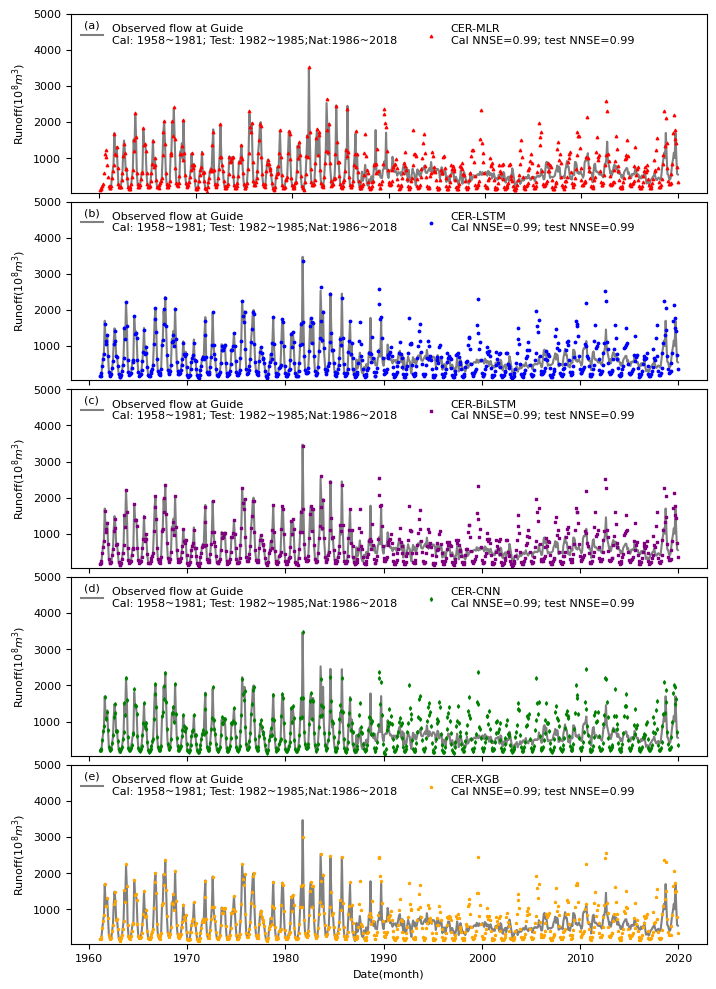

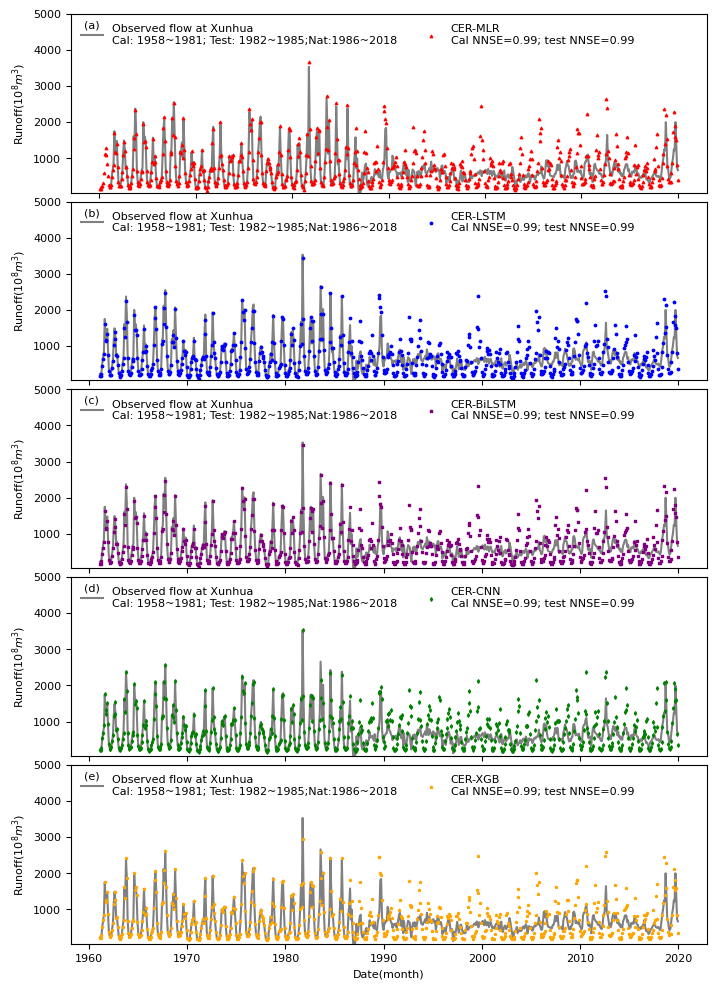

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import calendar

for hydro_station in hydro_stations:
    # Read data files
    CER_XGB = pd.read_csv(f'../results/vif_xgb_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_LSTM = pd.read_csv(f'../results/vif_lstm_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_BiLSTM = pd.read_csv(f'../results/vif_bilstm_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_CNN = pd.read_csv(f'../results/vif_cnn_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()
    CER_MLR = pd.read_csv(f'../results/vif_mlr_{hydro_station.lower()}.csv',index_col=['date'],parse_dates=['date']).sort_index()

    # Get observed flow data
    obs_flow = CER_BiLSTM.loc[:,['flow']]
    ftsize = 8
    
    # Create figure with 5 subplots (one for each model)
    fig = plt.figure(figsize=(7.48, 10.00))
    axes = [fig.add_subplot(5, 1, i+1) for i in range(5)]
    
    marker_size = 3
    
    # Plot observed flow as background
    for ax in axes:
        ax.plot(obs_flow.index, obs_flow, color='gray', 
                label=f'Observed flow at {hydro_station}\nCal: 1958~1981; Test: 1982~1985;Nat:1986~2018', 
                zorder=0)
    
    # Plot each model's results
    models = {
        'CER-MLR': (CER_MLR, 'red', '^'),
        'CER-LSTM': (CER_LSTM, 'blue', 'o'),
        'CER-BiLSTM': (CER_BiLSTM, 'purple', 's'),
        'CER-CNN': (CER_CNN, 'green', 'd'),
        'CER-XGB': (CER_XGB, 'orange', '*')
    }
    
    for idx, (model_name, (data, color, marker)) in enumerate(models.items()):
        axes[idx].scatter(data.index, data[model_name], color=color, marker=marker, 
                         s=marker_size, label=f'{model_name}\nCal NNSE=0.99; test NNSE=0.99', 
                         zorder=1)
        axes[idx].text(0.02, 0.92, f'({chr(97+idx)})', transform=axes[idx].transAxes, fontsize=ftsize)
    
    # Hide x-axis ticks for all but last subplot
    for ax in axes[:-1]:
        ax.set_xticklabels([])
    
    # Set y-labels and x-label
    for ax in axes:
        ax.set_ylabel('Runoff($10^8m^3$)', fontsize=ftsize)
    axes[-1].set_xlabel('Date(month)', fontsize=ftsize)
    
    # Set y-limits and legend for all subplots
    for ax in axes:
        ax.set_ylim([50, 5000])
        ax.legend(loc='upper left', ncol=2, shadow=False, frameon=False, fontsize=ftsize)
    
    # Adjust subplot spacing
    plt.subplots_adjust(left=0.10, bottom=0.05, right=0.95, top=0.98, hspace=0.05)
    
    # Save figure
    plt.savefig(f'../figs/naturalization_1958_2018_{hydro_station.lower()}.tif', 
                format='TIFF', dpi=500, bbox_inches='tight')
    
    plt.show()

In [48]:
for hydro_station in hydro_stations:
    preINF_metrics_CER_XGB = pd.read_csv(f'../results/vif_xgb_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_CER_LSTM = pd.read_csv(f'../results/vif_lstm_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_CER_BiLSTM = pd.read_csv(f'../results/vif_bilstm_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_CER_CNN = pd.read_csv(f'../results/vif_cnn_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_CER_MLR = pd.read_csv(f'../results/vif_mlr_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_E_XGB = pd.read_csv(f'../results/xgb(Extension)_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_E_LSTM = pd.read_csv(f'../results/lstm(Extension)_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_E_BiLSTM = pd.read_csv(f'../results/bilstm(Extension)_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_E_CNN = pd.read_csv(f'../results/cnn(Extension)_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_E_MLR = pd.read_csv(f'../results/mlr(Extension)_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_R_XGB = pd.read_csv(f'../results/xgb(Routing)_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_R_LSTM = pd.read_csv(f'../results/lstm(Routing)_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_R_BiLSTM = pd.read_csv(f'../results/bilstm(Routing)_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_R_CNN = pd.read_csv(f'../results/cnn(Routing)_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    preINF_metrics_R_MLR = pd.read_csv(f'../results/mlr(Routing)_metrics_{hydro_station.lower()}.csv',index_col=['period'])
    cal_metrics = pd.DataFrame()

    test_metrics = pd.DataFrame()
    
    # Calculate metrics for each model
    cal_metrics['CER-XGB'] = preINF_metrics_CER_XGB.loc['cal',:].values
    cal_metrics['CER-LSTM'] = preINF_metrics_CER_LSTM.loc['cal',:].values
    cal_metrics['CER-BiLSTM'] = preINF_metrics_CER_BiLSTM.loc['cal',:].values
    cal_metrics['CER-CNN'] = preINF_metrics_CER_CNN.loc['cal',:].values
    cal_metrics['CER-MLR'] = preINF_metrics_CER_MLR.loc['cal',:].values

    cal_metrics['E_XGB'] = preINF_metrics_E_XGB.loc['cal',:].values  
    cal_metrics['E_LSTM'] = preINF_metrics_E_LSTM.loc['cal',:].values
    cal_metrics['E_BiLSTM'] = preINF_metrics_E_BiLSTM.loc['cal',:].values
    cal_metrics['E_CNN'] = preINF_metrics_E_CNN.loc['cal',:].values
    cal_metrics['E_MLR'] = preINF_metrics_E_MLR.loc['cal',:].values

    cal_metrics['R_XGB'] = preINF_metrics_R_XGB.loc['cal',:].values  
    cal_metrics['R_LSTM'] = preINF_metrics_R_LSTM.loc['cal',:].values
    cal_metrics['R_BiLSTM'] = preINF_metrics_R_BiLSTM.loc['cal',:].values
    cal_metrics['R_CNN'] = preINF_metrics_R_CNN.loc['cal',:].values
    cal_metrics['R_MLR'] = preINF_metrics_R_MLR.loc['cal',:].values

    # Set index and calculate variance for each metric
    cal_metrics.index = preINF_metrics_CER_XGB.columns.values
    cal_metrics.index.name = 'index'
    cal_metrics.to_csv(f'../results/{hydro_station.lower()}_cal_metrics.csv')
    
    # Calculate variance for each metric across all models
    cal_metrics = cal_metrics.drop(['E_XGB','E_LSTM','E_BiLSTM','E_CNN','E_MLR',],axis=1)
    metric_variance = cal_metrics.var(axis=1)
    
    # Sort metrics by variance in descending order
    sorted_metrics = metric_variance.sort_values(ascending=False)
    
    # Print top 10 metrics with highest variance
    print("\nTop 10 metrics with highest variance across models:")
    print(sorted_metrics.head(10))


    test_metrics['CER-XGB'] = preINF_metrics_CER_XGB.loc['test',:].values
    test_metrics['CER-LSTM'] = preINF_metrics_CER_LSTM.loc['test',:].values
    test_metrics['CER-BiLSTM'] = preINF_metrics_CER_BiLSTM.loc['test',:].values
    test_metrics['CER-CNN'] = preINF_metrics_CER_CNN.loc['test',:].values
    test_metrics['CER-MLR'] = preINF_metrics_CER_MLR.loc['test',:].values

    test_metrics['E_XGB'] = preINF_metrics_E_XGB.loc['test',:].values  
    test_metrics['E_LSTM'] = preINF_metrics_E_LSTM.loc['test',:].values
    test_metrics['E_BiLSTM'] = preINF_metrics_E_BiLSTM.loc['test',:].values
    test_metrics['E_CNN'] = preINF_metrics_E_CNN.loc['test',:].values
    test_metrics['E_MLR'] = preINF_metrics_E_MLR.loc['test',:].values

    test_metrics['R_XGB'] = preINF_metrics_R_XGB.loc['test',:].values  
    test_metrics['R_LSTM'] = preINF_metrics_R_LSTM.loc['test',:].values
    test_metrics['R_BiLSTM'] = preINF_metrics_R_BiLSTM.loc['test',:].values
    test_metrics['R_CNN'] = preINF_metrics_R_CNN.loc['test',:].values
    test_metrics['R_MLR'] = preINF_metrics_R_MLR.loc['test',:].values

    test_metrics.index = preINF_metrics_CER_XGB.columns.values
    test_metrics.index.name = 'index'

    test_metrics.to_csv(f'../results/{hydro_station.lower()}_test_metrics.csv')



Top 10 metrics with highest variance across models:
index
MSE      385549.066848
MDSE      34830.305154
ED        17588.607017
PPMAE       449.346149
ME          146.464705
MDE         116.509116
RMSE         70.780328
MAE          63.391680
MDAE         53.431238
LPMAE        41.392286
dtype: float64

Top 10 metrics with highest variance across models:
index
MSE      725599.818194
MDSE     119433.592375
ED        25531.689446
PPMAE       393.858397
ME          276.974672
MDE         200.630946
MAE         151.922194
MDAE        105.561287
RMSE         97.331679
LPMAE        74.089944
dtype: float64


Estimation Results of Natural Flow in Seasonal Scale

In [49]:
for hydro_station in hydro_stations:
    flow = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    
    # read the results of CER(XGBoost) model
    vif_xgb_df = pd.read_csv(f'../results/vif_xgb_{hydro_station.lower()}.csv',parse_dates=['date'],index_col='date')
    vif_xgb_df = vif_xgb_df.sort_index()
    xgboost_predictions = vif_xgb_df.loc['1986-01-01':'2018-12-31',['CER-XGB']]
    season = []
    for year in range(xgboost_predictions.index.year.min(),xgboost_predictions.index.year.max()+1):
        for month in range(1,13):
            days = calendar.monthrange(year, month)[1]
            # print(year,month,days)
            date = pd.to_datetime(f'{year}-{month}-{days}')
            if month in [12,1,2]:
                season.append(str(year-1)+'-4')
            if month in [3,4,5]:
                season.append(str(year)+'-1')
            if month in [6,7,8]:
                season.append(str(year)+'-2')
            if month in [9,10,11]:
                season.append(str(year)+'-3')
    xgboost_predictions['season'] = season
    xgboost_predictions = xgboost_predictions.groupby('season').mean()
    xgboost_predictions = xgboost_predictions[xgboost_predictions.index>='1986-1']
    xgboost_predictions = xgboost_predictions[xgboost_predictions.index<='2015-4']

    # read the results of CER(LSTM) model
    vif_lstm_df = pd.read_csv(f'../results/vif_lstm_{hydro_station.lower()}.csv',parse_dates=['date'],index_col='date')
    vif_lstm_df = vif_lstm_df.sort_index()
    lstm_predictions = vif_lstm_df.loc['1986-01-01':'2018-12-31',['CER-LSTM']]
    season = []
    for year in range(lstm_predictions.index.year.min(),lstm_predictions.index.year.max()+1):
        for month in range(1,13):
            days = calendar.monthrange(year, month)[1]
            date = pd.to_datetime(f'{year}-{month}-{days}')
            if month in [12,1,2]:
                season.append(str(year-1)+'-4')
            if month in [3,4,5]:
                season.append(str(year)+'-1')
            if month in [6,7,8]:
                season.append(str(year)+'-2')
            if month in [9,10,11]:
                season.append(str(year)+'-3')
    lstm_predictions['season'] = season
    lstm_predictions = lstm_predictions.groupby('season').mean()
    lstm_predictions = lstm_predictions[lstm_predictions.index>='1986-1']
    lstm_predictions = lstm_predictions[lstm_predictions.index<='2015-4']

    # read the results of CER(BiLSTM) model
    vif_bilstm_df = pd.read_csv(f'../results/vif_bilstm_{hydro_station.lower()}.csv',parse_dates=['date'],index_col='date')
    vif_bilstm_df = vif_bilstm_df.sort_index()
    bilstm_predictions = vif_bilstm_df.loc['1986-01-01':'2018-12-31',['CER-BiLSTM']]
    season = []
    for year in range(bilstm_predictions.index.year.min(),bilstm_predictions.index.year.max()+1):
        for month in range(1,13):
            days = calendar.monthrange(year, month)[1]
            date = pd.to_datetime(f'{year}-{month}-{days}')
            if month in [12,1,2]:
                season.append(str(year-1)+'-4')
            if month in [3,4,5]:
                season.append(str(year)+'-1')   
            if month in [6,7,8]:
                season.append(str(year)+'-2')
            if month in [9,10,11]:
                season.append(str(year)+'-3')
    bilstm_predictions['season'] = season
    bilstm_predictions = bilstm_predictions.groupby('season').mean()
    bilstm_predictions = bilstm_predictions[bilstm_predictions.index>='1986-1']
    bilstm_predictions = bilstm_predictions[bilstm_predictions.index<='2015-4']
    
    # read the results of CER(CNN) model
    vif_cnn_df = pd.read_csv(f'../results/vif_cnn_{hydro_station.lower()}.csv',parse_dates=['date'],index_col='date')
    # Sort the index to ensure monotonicity
    vif_cnn_df = vif_cnn_df.sort_index()
    # Filter the date range after sorting
    cnn_predictions = vif_cnn_df.loc['1986-01-01':'2018-12-31',['CER-CNN']]
    season = []
    for year in range(cnn_predictions.index.year.min(),cnn_predictions.index.year.max()+1):
        for month in range(1,13):
            days = calendar.monthrange(year, month)[1]
            date = pd.to_datetime(f'{year}-{month}-{days}')
            if month in [12,1,2]:
                season.append(str(year-1)+'-4')
            if month in [3,4,5]:
                season.append(str(year)+'-1')   
            if month in [6,7,8]:
                season.append(str(year)+'-2')
            if month in [9,10,11]:
                season.append(str(year)+'-3')
    cnn_predictions['season'] = season
    cnn_predictions = cnn_predictions.groupby('season').mean()
    cnn_predictions = cnn_predictions[cnn_predictions.index>='1986-1']
    cnn_predictions = cnn_predictions[cnn_predictions.index<='2015-4']
    
    # read the results of CER(MLR) model
    vif_mlr_df = pd.read_csv(f'../results/vif_mlr_{hydro_station.lower()}.csv',parse_dates=['date'],index_col='date')
    vif_mlr_df = vif_mlr_df.sort_index()
    mlr_predictions = vif_mlr_df.loc['1986-01-01':'2018-12-31',['CER-MLR']]
    season = []
    for year in range(mlr_predictions.index.year.min(),mlr_predictions.index.year.max()+1):
        for month in range(1,13):
            days = calendar.monthrange(year, month)[1]
            date = pd.to_datetime(f'{year}-{month}-{days}')
            if month in [12,1,2]:
                season.append(str(year-1)+'-4')
            if month in [3,4,5]:
                season.append(str(year)+'-1')
            if month in [6,7,8]:
                season.append(str(year)+'-2')
            if month in [9,10,11]:
                season.append(str(year)+'-3')
    mlr_predictions['season'] = season
    mlr_predictions = mlr_predictions.groupby('season').mean()
    mlr_predictions = mlr_predictions[mlr_predictions.index>='1986-1']
    mlr_predictions = mlr_predictions[mlr_predictions.index<='2015-4']  
    
    
    seasonal_flow = pd.read_csv(f'../results/{hydro_station}_seasonal_naturalization.csv',index_col=['YQ'])
    seasonal_flow['CER-XGB'] = xgboost_predictions.values
    seasonal_flow['CER-LSTM'] = lstm_predictions.values
    seasonal_flow['CER-BiLSTM'] = bilstm_predictions.values
    seasonal_flow['CER-CNN'] = cnn_predictions.values
    seasonal_flow['CER-MLR'] = mlr_predictions.values
    print(seasonal_flow)
    seasonal_flow.to_csv(f'../results/{hydro_station}_seasonal_naturalization.csv')


        natural_flow      VIF_MLR     VIF_LSTM  VIF_LSTM_MLR      VIF_XGB  \
YQ                                                                          
1986-1           487   480.584115   487.467620    489.168503   495.776060   
1986-2          1175  1209.538985  1200.289833   1196.930287  1198.927767   
1986-3           705   704.068777   706.613100    690.111303   702.821310   
1986-4           216   181.472171   171.431183    187.980534   186.114713   
1987-1           377   350.912961   338.935807    348.855220   331.533347   
...              ...          ...          ...           ...          ...   
2014-4           230   241.611354   216.577563    240.023181   226.064567   
2015-1           355   319.035019   310.543177    311.813293   307.731373   
2015-2           795   877.350993   874.090100    872.456133   811.030100   
2015-3           570   618.247769   610.847720    603.432687   575.169993   
2015-4           178   194.794075   179.629140    193.406078   177.945897   

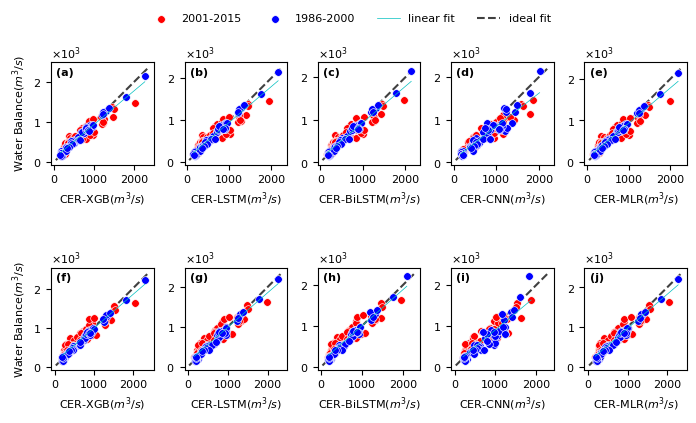

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import calendar
import seaborn as sns
import numpy as np
from scipy import stats

# Set figure size and create 2x5 subplot grid
plt.rcParams.update({'font.size': 8})
fig = plt.figure(figsize=(7.48, 4.0))

# Create subplots
axes = []
for i in range(2):
    for j in range(5):
        ax = plt.subplot2grid((2, 5), (i, j), aspect='equal')
        axes.append(ax)

# Read and process data for each station
for station_idx, hydro_station in enumerate(hydro_stations):
    # Read data files
    seasonal_flow = pd.read_csv(f'../results/{hydro_station}_seasonal_naturalization.csv', index_col=['YQ'])
    
    # Create mask for pre/post 2000 split
    pre2000 = seasonal_flow.index <= '2000-4'
    post2000 = seasonal_flow.index > '2000-4'
    
    # Plot each model's results
    models = ['CER-XGB', 'CER-LSTM', 'CER-BiLSTM', 'CER-CNN', 'CER-MLR']
    for model_idx, model in enumerate(models):
        ax = axes[station_idx * 5 + model_idx]
        
        # Plot post-2000 data first (lower zorder)
        sns.scatterplot(x=seasonal_flow.loc[post2000, model],
                       y=seasonal_flow.loc[post2000, 'natural_flow'],
                       label='2001-2015', ax=ax, color='red', marker='o', s=30, zorder=1)
        
        # Plot pre-2000 data second (higher zorder)
        sns.scatterplot(x=seasonal_flow.loc[pre2000, model], 
                       y=seasonal_flow.loc[pre2000, 'natural_flow'],
                       label='1986-2000', ax=ax, color='blue', marker='o', s=30, zorder=2)
        
        # Fit linear regression line for all data points
        x_all = seasonal_flow[model]
        y_all = seasonal_flow['natural_flow']
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_all, y_all)
        x_line = np.array([x_all.min(), x_all.max()])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'c-', linewidth=0.5,zorder=3, label='linear fit' if model_idx == 4 else None)
        
        # Add 1:1 line
        lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),
            np.max([ax.get_xlim(), ax.get_ylim()]),
        ]
        ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='ideal fit' if model_idx == 4 else None)
        
        # Set labels and format
        ax.set_xlabel(f'{model}($m^3/s$)')
        if model_idx == 0:  # Only first column needs y-label
            ax.set_ylabel('Water Balance($m^3/s$)')
        else:
            ax.set_ylabel('')
            
        # Add subplot labels
        label = f'({chr(97 + station_idx * 5 + model_idx)})'
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        x_pos = xlim[0] + 0.05 * (xlim[1] - xlim[0])
        y_pos = ylim[1] - 0.05 * (ylim[1] - ylim[0])
        ax.text(x_pos, y_pos, label, ha='left', va='top', fontweight='bold')
        
        # Format scientific notation only for y-axis
        ax.ticklabel_format(style='sci', scilimits=(-1,2), axis='y', useMathText=True)
        ax.grid(False)

# Handle legend
handles, labels = [], []
for ax in axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label not in labels:
            handles.append(handle)
            labels.append(label)
    legend = ax.legend()
    legend.remove()

fig.legend(handles, labels,
          ncol=4,
          frameon=False,
          bbox_to_anchor=(0.5, 1.05),
          loc='upper center')

# Adjust subplot spacing
plt.subplots_adjust(left=0.1, bottom=0.08, right=0.95, top=0.96, 
                   hspace=0.4, wspace=0.3)

# Save figures
plt.savefig('../figs/compare_naturalization_results.tif', format='TIFF', dpi=500, bbox_inches='tight')
plt.savefig('../figs/compare_naturalization_results.png', format='PNG', dpi=300, bbox_inches='tight')


C:\Users\ZJY\AppData\Local\Temp\ipykernel_144212\547929108.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45,fontsize=ftsize)
C:\Users\ZJY\AppData\Local\Temp\ipykernel_144212\547929108.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45,fontsize=ftsize)


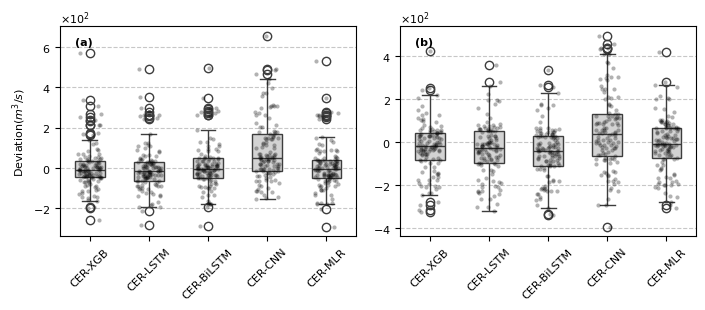

C:\Users\ZJY\AppData\Local\Temp\ipykernel_144212\547929108.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45,fontsize=ftsize)
C:\Users\ZJY\AppData\Local\Temp\ipykernel_144212\547929108.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45,fontsize=ftsize)


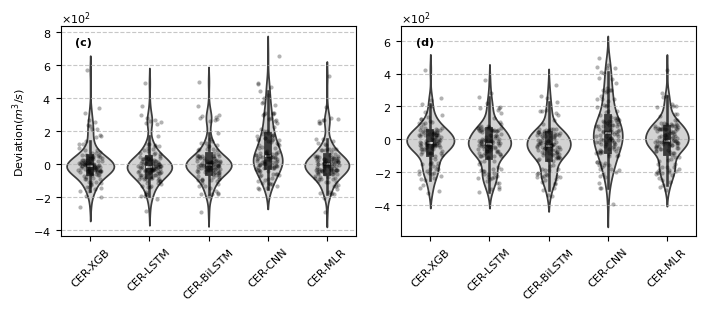

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import calendar
import seaborn as sns

deviations_dict = {}

for hydro_station in hydro_stations:
    # Read data files
    seasonal_flow = pd.read_csv(f'../results/{hydro_station}_seasonal_naturalization.csv',index_col=['YQ'])
    deviations = pd.DataFrame(index=seasonal_flow.index)
    deviations['CER-XGB'] = seasonal_flow.loc[:,['CER-XGB']].values.flatten() - seasonal_flow.loc[:,['natural_flow']].values.flatten()
    deviations['CER-LSTM'] = seasonal_flow.loc[:,['CER-LSTM']].values.flatten() - seasonal_flow.loc[:,['natural_flow']].values.flatten()    
    deviations['CER-BiLSTM'] = seasonal_flow.loc[:,['CER-BiLSTM']].values.flatten() - seasonal_flow.loc[:,['natural_flow']].values.flatten()
    deviations['CER-CNN'] = seasonal_flow.loc[:,['CER-CNN']].values.flatten() - seasonal_flow.loc[:,['natural_flow']].values.flatten()
    deviations['CER-MLR'] = seasonal_flow.loc[:,['CER-MLR']].values.flatten() - seasonal_flow.loc[:,['natural_flow']].values.flatten()
    deviations_dict[hydro_station] = deviations

# Create figure for boxplot
fig1 = plt.figure(figsize=(7.48, 3.0))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122)

# Create boxplots with individual points for Guide station
sns.boxplot(data=deviations_dict['Guide'], ax=ax1, width=0.5, color='lightgray')
sns.stripplot(data=deviations_dict['Guide'], ax=ax1, size=3, color='black', alpha=0.3, jitter=0.2)

# Create boxplots with individual points for Xunhua station
sns.boxplot(data=deviations_dict['Xunhua'], ax=ax2, width=0.5, color='lightgray')
sns.stripplot(data=deviations_dict['Xunhua'], ax=ax2, size=3, color='black', alpha=0.3, jitter=0.2)

# Customize boxplots
# ax1.set_title('Guide Station',fontsize=ftsize)
# ax2.set_title('Xunhua Station',fontsize=ftsize)
ax1.set_ylabel('Deviation($m^3/s$)',fontsize=ftsize)
ax2.set_ylabel('')  # Remove y-axis label for second subplot

# Add subplot labels for boxplots
ax1.text(0.05, 0.95, '(a)', transform=ax1.transAxes, fontweight='bold', va='top')
ax2.text(0.05, 0.95, '(b)', transform=ax2.transAxes, fontweight='bold', va='top')

# Format scientific notation and add grid for boxplots
for ax in [ax1, ax2]:
    ax.ticklabel_format(style='sci', scilimits=(-1,2), axis='y', useMathText=True)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45,fontsize=ftsize)

# Adjust layout for boxplots
plt.subplots_adjust(left=0.1, bottom=0.2, right=0.95, top=0.9, wspace=0.15)

# Save boxplot figures
plt.savefig('../figs/model_deviations_boxplot.tif',format='TIFF', dpi=500, bbox_inches='tight')
plt.savefig('../figs/model_deviations_boxplot.png',format='PNG', dpi=300, bbox_inches='tight')
plt.show()

# Create figure for violin plot
fig2 = plt.figure(figsize=(7.48, 3.0))
ax3 = plt.subplot(121)
ax4 = plt.subplot(122)

# Create violin plots for Guide station
sns.violinplot(data=deviations_dict['Guide'], ax=ax3, inner='box', color='lightgray')
sns.stripplot(data=deviations_dict['Guide'], ax=ax3, size=3, color='black', alpha=0.3, jitter=0.2)

# Create violin plots for Xunhua station
sns.violinplot(data=deviations_dict['Xunhua'], ax=ax4, inner='box', color='lightgray')
sns.stripplot(data=deviations_dict['Xunhua'], ax=ax4, size=3, color='black', alpha=0.3, jitter=0.2)

# Customize violin plots
# ax3.set_title('Guide Station',fontsize=ftsize)
# ax4.set_title('Xunhua Station',fontsize=ftsize)
ax3.set_ylabel('Deviation($m^3/s$)',fontsize=ftsize)
ax4.set_ylabel('')  # Remove y-axis label for second subplot

# Add subplot labels for violin plots
ax3.text(0.05, 0.95, '(c)', transform=ax3.transAxes, fontweight='bold', va='top')
ax4.text(0.05, 0.95, '(d)', transform=ax4.transAxes, fontweight='bold', va='top')

# Format scientific notation and add grid for violin plots
for ax in [ax3, ax4]:
    ax.ticklabel_format(style='sci', scilimits=(-1,2), axis='y', useMathText=True)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45,fontsize=ftsize)

# Adjust layout for violin plots
plt.subplots_adjust(left=0.1, bottom=0.2, right=0.95, top=0.9, wspace=0.15)

# Save violin plot figures
plt.savefig('../figs/model_deviations_violin.tif',format='TIFF', dpi=500, bbox_inches='tight')
plt.savefig('../figs/model_deviations_violin.png',format='PNG', dpi=300, bbox_inches='tight')
plt.show()

In [52]:
for hydro_station in hydro_stations:
    seasonal_flow = pd.read_csv(f'../results/{hydro_station}_seasonal_naturalization.csv',index_col=['YQ'])
    metrics = pd.DataFrame(index=['CER-XGB','CER-LSTM','CER-BiLSTM','CER-CNN','CER-MLR'])
    metrics['ME']=[
        he.me(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.me(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.me(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.me(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.me(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MAE']=[
        he.mae(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mae(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mae(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mae(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mae(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MSE']=[
        he.mse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MLE']=[
        he.mle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MALE']=[
        he.male(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.male(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.male(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.male(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.male(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MSLE']=[
        he.msle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.msle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.msle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.msle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.msle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MAPE']=[
        he.mape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MDE']=[
        he.mde(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mde(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mde(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mde(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mde(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MDAE']=[
        he.mdae(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mdae(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mdae(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mdae(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mdae(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MDSE']=[
        he.mdse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mdse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mdse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mdse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mdse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['ED']=[
        he.ed(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.ed(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.ed(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.ed(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.ed(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['NED']=[
        he.ned(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.ned(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.ned(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.ned(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.ned(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['RMSE']=[
        he.rmse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.rmse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.rmse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.rmse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.rmse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['RMSLE']=[
        he.rmsle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.rmsle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.rmsle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.rmsle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.rmsle(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['NRMSE_RANGE']=[
        he.nrmse_range(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.nrmse_range(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.nrmse_range(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.nrmse_range(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.nrmse_range(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['NRMSE_MEAN']=[
        he.nrmse_mean(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.nrmse_mean(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.nrmse_mean(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.nrmse_mean(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.nrmse_mean(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['NRMSE_IQR']=[
        he.nrmse_iqr(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.nrmse_iqr(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.nrmse_iqr(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.nrmse_iqr(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.nrmse_iqr(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['IRMSE']=[
        he.irmse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.irmse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.irmse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.irmse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.irmse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MASE']=[
        he.mase(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mase(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mase(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mase(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mase(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['R_SQUARED']=[
        he.r_squared(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.r_squared(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.r_squared(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.r_squared(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.r_squared(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['PEARSON_R']=[
        he.pearson_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.pearson_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.pearson_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.pearson_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.pearson_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['SPEARMAN_R']=[
        he.spearman_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.spearman_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.spearman_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.spearman_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.spearman_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['ACC']=[
        he.acc(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.acc(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.acc(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.acc(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.acc(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MAPE']=[
        he.mape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MAPD']=[
        he.mapd(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mapd(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mapd(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mapd(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mapd(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MAAPE']=[
        he.maape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.maape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.maape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.maape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.maape(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['SMAPE1']=[
        he.smape1(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.smape1(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.smape1(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.smape1(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.smape1(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['SMAPE2']=[
        he.smape2(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.smape2(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.smape2(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.smape2(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.smape2(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['D']=[
        he.d(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.d(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.d(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.d(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.d(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['D1']=[
        he.d1(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.d1(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.d1(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.d1(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.d1(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['DMOD']=[
        he.dmod(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.dmod(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.dmod(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.dmod(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.dmod(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['DREL']=[
        he.drel(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.drel(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.drel(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.drel(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.drel(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['DR']=[
        he.dr(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.dr(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.dr(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.dr(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.dr(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['WATT_M']=[
        he.watt_m(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.watt_m(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.watt_m(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.watt_m(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.watt_m(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MB_R']=[
        he.mb_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mb_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mb_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mb_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mb_r(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['NSE']=[
        he.nse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.nse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.nse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.nse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.nse(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['NSE_MOD']=[
        he.nse_mod(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.nse_mod(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.nse_mod(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.nse_mod(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.nse_mod(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['NSE_REL']=[
        he.nse_rel(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.nse_rel(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.nse_rel(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.nse_rel(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.nse_rel(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['KGE_2009']=[
        he.kge_2009(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.kge_2009(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.kge_2009(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.kge_2009(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.kge_2009(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['KGE_2012']=[
        he.kge_2012(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.kge_2012(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.kge_2012(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.kge_2012(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.kge_2012(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['LM_INDEX']=[
        he.lm_index(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.lm_index(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.lm_index(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.lm_index(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.lm_index(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['D1_P']=[
        he.d1_p(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.d1_p(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.d1_p(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.d1_p(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.d1_p(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['VE']=[
        he.ve(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.ve(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.ve(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.ve(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.ve(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['SA']=[
        he.sa(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.sa(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.sa(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.sa(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.sa(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['SC']=[
        he.sc(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.sc(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.sc(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.sc(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.sc(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['SID']=[
        he.sid(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.sid(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.sid(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.sid(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.sid(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['SGA']=[
        he.sga(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.sga(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.sga(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.sga(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.sga(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H1_MHE']=[
        he.h1_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h1_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h1_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h1_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h1_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H1_MAHE']=[
        he.h1_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h1_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h1_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h1_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h1_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H1_RMSHE']=[
        he.h1_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h1_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h1_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h1_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h1_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H2_MHE']=[
        he.h2_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h2_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h2_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h2_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h2_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H2_MAHE']=[
        he.h2_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h2_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h2_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h2_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h2_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H2_RMSHE']=[
        he.h2_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h2_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h2_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h2_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h2_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H3_MHE']=[
        he.h3_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h3_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h3_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h3_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h3_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H3_MAHE']=[
        he.h3_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h3_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h3_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h3_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h3_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H3_RMSHE']=[
        he.h3_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h3_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h3_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h3_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h3_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H4_MHE']=[
        he.h4_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h4_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h4_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h4_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h4_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H4_MAHE']=[
        he.h4_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h4_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h4_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h4_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h4_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H4_RMSHE']=[
        he.h4_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h4_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h4_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h4_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h4_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H5_MHE']=[
        he.h5_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h5_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h5_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h5_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h5_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H5_MAHE']=[
        he.h5_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h5_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h5_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h5_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h5_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H5_RMSHE']=[
        he.h5_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h5_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h5_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h5_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h5_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H6_MHE']=[
        he.h6_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h6_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h6_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h6_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h6_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H6_MAHE']=[
        he.h6_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h6_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h6_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h6_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h6_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H6_RMSHE']=[
        he.h6_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h6_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h6_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h6_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h6_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H7_MHE']=[
        he.h7_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h7_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h7_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h7_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h7_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H7_MAHE']=[
        he.h7_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h7_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h7_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h7_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h7_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H7_RMSHE']=[   
        he.h7_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h7_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h7_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h7_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h7_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H8_MHE']=[
        he.h8_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h8_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h8_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h8_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h8_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H8_MAHE']=[
        he.h8_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h8_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h8_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h8_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h8_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H8_RMSHE']=[
        he.h8_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h8_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h8_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h8_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h8_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H10_MHE']=[
        he.h10_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h10_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h10_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h10_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h10_mhe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H10_MAHE']=[
        he.h10_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h10_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h10_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h10_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h10_mahe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['H10_RMSHE']=[
        he.h10_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.h10_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.h10_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.h10_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.h10_rmshe(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['G_MEAN_DIFF']=[
        he.g_mean_diff(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.g_mean_diff(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.g_mean_diff(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.g_mean_diff(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.g_mean_diff(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['MEAN_VAR']=[
        he.mean_var(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-XGB']),
        he.mean_var(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-LSTM']),
        he.mean_var(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-BiLSTM']),
        he.mean_var(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-CNN']),
        he.mean_var(observed_array=seasonal_flow['natural_flow'],simulated_array=seasonal_flow['CER-MLR'])
    ]
    metrics['PPMAE']=[
        PPMAE(y_true=seasonal_flow['natural_flow'],y_pred=seasonal_flow['CER-XGB']),
        PPMAE(y_true=seasonal_flow['natural_flow'],y_pred=seasonal_flow['CER-LSTM']),
        PPMAE(y_true=seasonal_flow['natural_flow'],y_pred=seasonal_flow['CER-BiLSTM']),
        PPMAE(y_true=seasonal_flow['natural_flow'],y_pred=seasonal_flow['CER-CNN']),
        PPMAE(y_true=seasonal_flow['natural_flow'],y_pred=seasonal_flow['CER-MLR'])
    ]
    metrics['LPMAE']=[
        LPMAE(y_true=seasonal_flow['natural_flow'],y_pred=seasonal_flow['CER-XGB']),
        LPMAE(y_true=seasonal_flow['natural_flow'],y_pred=seasonal_flow['CER-LSTM']),
        LPMAE(y_true=seasonal_flow['natural_flow'],y_pred=seasonal_flow['CER-BiLSTM']),
        LPMAE(y_true=seasonal_flow['natural_flow'],y_pred=seasonal_flow['CER-CNN']),
        LPMAE(y_true=seasonal_flow['natural_flow'],y_pred=seasonal_flow['CER-MLR'])
    ]
    metrics.index.name='Model'
    metrics.to_csv(f'../results/{hydro_station.lower()}_CER_Models_Seasonal_metrics.csv',index=True)

-------------------- Guide --------------------
['v10', 'AVG-TEM(C)', 'smlt', 'sro', 'sd', 'ssro', 'tnh_flow']
-------------------- Xunhua --------------------
['smlt', 'sro', 'evabs', 'ssro', 'v10', 'sd', 'tnh_flow']


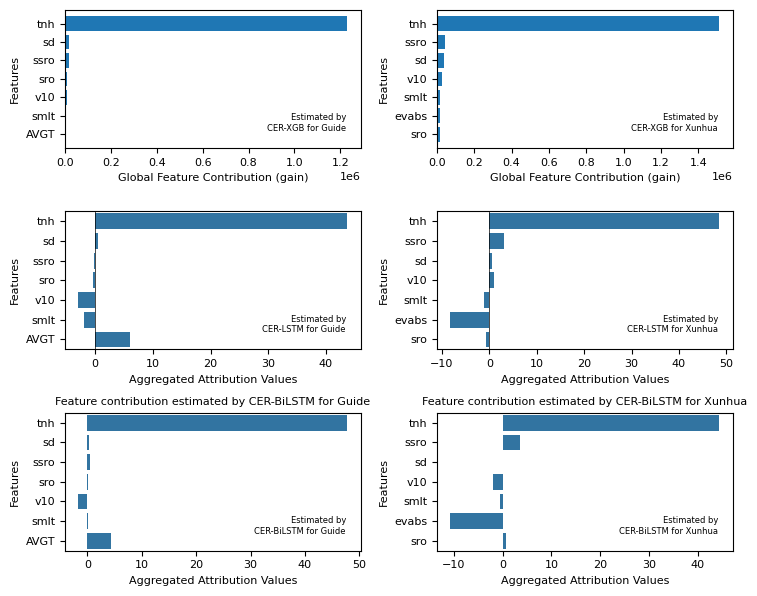

In [53]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from captum.attr import IntegratedGradients
from sklearn.preprocessing import MinMaxScaler
from Dataset import SimulatedSequenceDataset
from torch.utils.data import Dataset, DataLoader, TensorDataset,Subset
from OneShotSamplesGenerator import gen_one_out_samples
from MultiOutXGBRegressor import load_model as load_xgb_model
from LSTMRegressor import load_best_trial as load_lstm_best_trial
from LSTMRegressor import load_model as load_lstm_model
from LSTMRegressor import DEVICE
from BiLSTMRegressor import load_best_trial as load_bilstm_best_trial
from BiLSTMRegressor import load_model as load_bilstm_model
from CNNRegressor import load_best_trial as load_cnn_best_trial
from CNNRegressor import load_model as load_cnn_model

hydro_stations = [
    'Guide',
    'Xunhua'
]

start_date = '1960-01-01'
end_date = '2019-12-31'

# Create figure with 3x2 subplots
plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(3, 2, figsize=(7.48, 6))

for col, hydro_station in enumerate(hydro_stations):
    # Get XGBoost global importance
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    df = df.rename(columns={'AVG-TEM(C)': 'AVGT'})
    samples,target,features = gen_one_out_samples(df,target_column='flow',mode='simulate',lags_dict=None,lag=12,lead=1)
    
    # Load trained XGBoost model
    model = load_xgb_model(f'../models/CER/{hydro_station.lower()}/XGBOOST_lag12/vif_xgb_model.json')

    # Group features by base name (without lag)
    feature_groups = {}
    for feature in features:
        base_name = feature.split('_')[0]  # Get base name before lag
        if base_name not in feature_groups:
            feature_groups[base_name] = []
        feature_groups[base_name].append(feature)

    # Get global feature importance
    global_importance = model.get_score(importance_type='gain')
    global_contributions = {}
    
    # Calculate aggregated importance for feature groups
    for base_name, feature_list in feature_groups.items():
        global_contributions[base_name] = sum(global_importance.get(f, 0) for f in feature_list)

    # Plot XGBoost global importance
    features_list = list(feature_groups.keys())
    global_importance_df = pd.DataFrame({
        'Predictors': features_list,
        'Importance': [global_contributions[f] for f in features_list]
    })
    
    # Sort features by importance and store the order
    global_importance_df = global_importance_df.sort_values('Importance', ascending=True)
    feature_order = global_importance_df['Predictors'].tolist()

    axes[0,col].barh(global_importance_df['Predictors'], global_importance_df['Importance'])
    axes[0,col].set_xlabel('Global Feature Contribution (gain)')
    axes[0,col].set_ylabel('Features')  # Added ylabel for first subplot
    # Add title inside the plot
    axes[0,col].text(0.95, 0.25, f'Estimated by\nCER-XGB for {hydro_station}',
                    transform=axes[0,col].transAxes, ha='right', va='top', fontsize=6,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    # Only show y-axis labels for the first column
    
    print("-"*20,hydro_station,"-"*20)
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    df = df.loc[start_date:end_date]

    target = 'flow'
    features = list(df.columns.difference([target]))
    features = list(df.columns.copy())
    features.remove(target)
    print(features)

    cal = df.loc[:'1982-12-31',:]
    test = df.loc['1982-01-01':'1985-12-31',:]
    pre = df.loc['1985-01-01':,:]

    X_scaler = MinMaxScaler(feature_range=(0,1))
    Y_scaler = MinMaxScaler(feature_range=(0,1))
    X_scaler.fit(cal[features])
    Y_scaler.fit(cal[[target]])

    cal_X = X_scaler.transform(cal[features])
    test_X = X_scaler.transform(test[features])
    pre_X = X_scaler.transform(pre[features])

    cal_y = Y_scaler.transform(cal[[target]])
    test_y = Y_scaler.transform(test[[target]])
    pre_y = Y_scaler.transform(pre[[target]])

    cal = pd.concat([pd.DataFrame(cal_X,columns=features,index=cal.index),pd.DataFrame(cal_y,columns=[target],index=cal.index)],axis=1)
    test = pd.concat([pd.DataFrame(test_X,columns=features,index=test.index),pd.DataFrame(test_y,columns=[target],index=test.index)],axis=1)
    pre = pd.concat([pd.DataFrame(pre_X,columns=features,index=pre.index),pd.DataFrame(pre_y,columns=[target],index=pre.index)],axis=1)

    sequence_length =12
    cal_dataset = SimulatedSequenceDataset(
        dataframe=cal.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    test_dataset = SimulatedSequenceDataset(
        dataframe=test.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    pre_dataset = SimulatedSequenceDataset(
        dataframe=pre.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    full_dataset = SimulatedSequenceDataset(
        dataframe=df.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )

    # Get LSTM global importance using Integrated Gradients
    model_path = f'../models/CER/{hydro_station.lower()}/LSTM_lag12/'
    best_trial = load_lstm_best_trial(model_path+'best_trial.pickle')
    model1 = load_lstm_model(model_path+'model.pickle').to(DEVICE)
    ig = IntegratedGradients(model1)

    cal_dataloader = DataLoader(cal_dataset)
    aggregated_attributions = []
    for inputs, labels in cal_dataloader:
        attributions = ig.attribute(inputs.to(DEVICE))
        aggregated_attributions.append(attributions.cpu())
    aggregated_attributions = torch.cat(aggregated_attributions, dim=0)
    attributions_np = aggregated_attributions.detach().numpy()
    sum_attributions = np.sum(attributions_np, axis=0)
    sum_attributions = np.sum(sum_attributions, axis=0)

    # Create DataFrame for LSTM attributions using same feature order as XGBoost
    lstm_df = pd.DataFrame({
        'Features': feature_order[::-1],  # Reverse the feature order
        'Attribution Values': [sum_attributions[features_list.index(f)] for f in feature_order[::-1]]  # Reverse the attribution values
    })
    
    sns.barplot(x='Attribution Values', y='Features', data=lstm_df, orient='h', ax=axes[1,col])
    axes[1,0].set_ylabel('Features')
    axes[1,col].set_xlabel('Aggregated Attribution Values')
    # Add title inside the plot
    axes[1,col].text(0.95, 0.25, f'Estimated by\nCER-LSTM for {hydro_station}',
                    transform=axes[1,col].transAxes, ha='right', va='top', fontsize=6,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    # Add vertical line at x=0 for LSTM plot
    axes[1,col].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    # Only show y-axis labels for the first column
    

    # Get BiLSTM global importance using Integrated Gradients
    model_path = f'../models/CER/{hydro_station.lower()}/BiLSTM_lag12/'
    best_trial = load_bilstm_best_trial(model_path+'best_trial.pickle')
    model2 = load_bilstm_model(model_path+'model.pickle').to(DEVICE)
    ig = IntegratedGradients(model2)

    cal_dataloader = DataLoader(cal_dataset)
    aggregated_attributions = []
    for inputs, labels in cal_dataloader:
        attributions = ig.attribute(inputs.to(DEVICE))
        aggregated_attributions.append(attributions.cpu())
    aggregated_attributions = torch.cat(aggregated_attributions, dim=0)
    attributions_np = aggregated_attributions.detach().numpy()
    sum_attributions = np.sum(attributions_np, axis=0)
    sum_attributions = np.sum(sum_attributions, axis=0)

    # Create DataFrame for BiLSTM attributions
    bilstm_df = pd.DataFrame({
        'Features': feature_order[::-1],
        'Attribution Values': [sum_attributions[features_list.index(f)] for f in feature_order[::-1]]
    })
    
    sns.barplot(x='Attribution Values', y='Features', data=bilstm_df, orient='h', ax=axes[2,col])
    axes[2,0].set_ylabel('Features')
    axes[2,col].set_xlabel('Aggregated Attribution Values')
    axes[2,col].set_title(f'Feature contribution estimated by CER-BiLSTM for {hydro_station}',fontsize=8)
    axes[2,col].text(0.95, 0.25, f'Estimated by\nCER-BiLSTM for {hydro_station}',
                    transform=axes[2,col].transAxes, ha='right', va='top', fontsize=6,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))  



fig.tight_layout()
plt.savefig('../figs/global_feature_importance_comparison.tif', format='TIFF', dpi=500, bbox_inches='tight')
plt.savefig('../figs/global_feature_importance_comparison.png', format='PNG', dpi=600, bbox_inches='tight')
plt.show()


-------------------- Guide --------------------
['v10', 'AVG-TEM(C)', 'smlt', 'sro', 'sd', 'ssro']
-------------------- Xunhua --------------------
['smlt', 'sro', 'evabs', 'ssro', 'v10', 'sd']


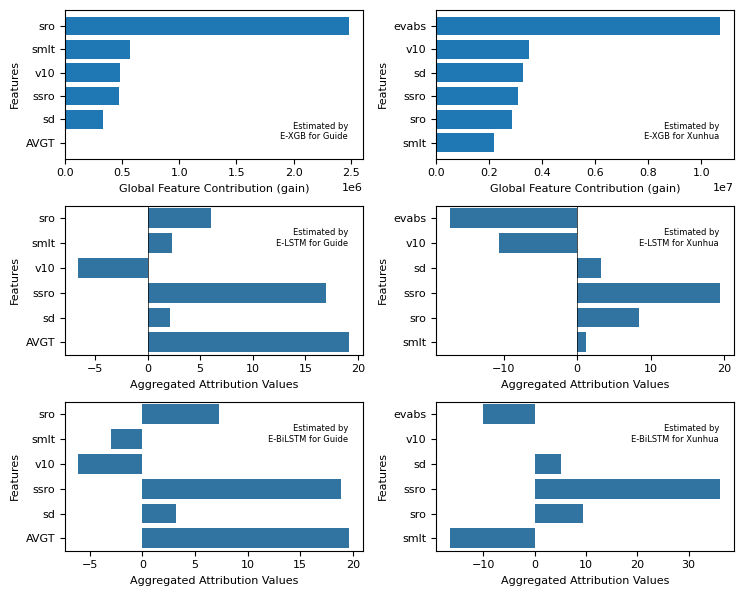

In [54]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from captum.attr import IntegratedGradients
from sklearn.preprocessing import MinMaxScaler
from Dataset import SimulatedSequenceDataset
from torch.utils.data import Dataset, DataLoader, TensorDataset,Subset
from OneShotSamplesGenerator import gen_one_out_samples
from MultiOutXGBRegressor import load_model as load_xgb_model
from LSTMRegressor import load_best_trial as load_lstm_best_trial
from LSTMRegressor import load_model as load_lstm_model
from LSTMRegressor import DEVICE
from BiLSTMRegressor import load_best_trial as load_bilstm_best_trial
from BiLSTMRegressor import load_model as load_bilstm_model
from CNNRegressor import load_best_trial as load_cnn_best_trial
from CNNRegressor import load_model as load_cnn_model

hydro_stations = [
    'Guide',
    'Xunhua'
]

start_date = '1960-01-01'
end_date = '2019-12-31'

# Create figure with 3x2 subplots
plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(3, 2, figsize=(7.48, 6))

for col, hydro_station in enumerate(hydro_stations): 
    # Get XGBoost global importance
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    df = df.rename(columns={'AVG-TEM(C)': 'AVGT'})
    df = df.drop('tnh_flow',axis=1)
    samples,target,features = gen_one_out_samples(df,target_column='flow',mode='simulate',lags_dict=None,lag=12,lead=1)
    
    # Load trained XGBoost model
    model = load_xgb_model(f'../models/Extension/{hydro_station.lower()}/XGBOOST_lag12/vif_xgb_model.json')

    # Group features by base name (without lag)
    feature_groups = {}
    for feature in features:
        base_name = feature.split('_')[0]  # Get base name before lag
        if base_name not in feature_groups:
            feature_groups[base_name] = []
        feature_groups[base_name].append(feature)

    # Get global feature importance
    global_importance = model.get_score(importance_type='gain')
    global_contributions = {}
    
    # Calculate aggregated importance for feature groups
    for base_name, feature_list in feature_groups.items():
        global_contributions[base_name] = sum(global_importance.get(f, 0) for f in feature_list)

    # Plot XGBoost global importance
    features_list = list(feature_groups.keys())
    global_importance_df = pd.DataFrame({
        'Predictors': features_list,
        'Importance': [global_contributions[f] for f in features_list]
    })
    
    # Sort features by importance and store the order
    global_importance_df = global_importance_df.sort_values('Importance', ascending=True)
    feature_order = global_importance_df['Predictors'].tolist()

    axes[0,col].barh(global_importance_df['Predictors'], global_importance_df['Importance'])
    axes[0,col].set_xlabel('Global Feature Contribution (gain)')
    axes[0,col].set_ylabel('Features')  # Added ylabel for first subplot
    # Add title inside the plot
    axes[0,col].text(0.95, 0.25, f'Estimated by\nE-XGB for {hydro_station}',
                    transform=axes[0,col].transAxes, ha='right', va='top', fontsize=6,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    # Only show y-axis labels for the first column
    
    print("-"*20,hydro_station,"-"*20)
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    df = df.loc[start_date:end_date]
    df = df.drop(columns=['tnh_flow'])

    target = 'flow'
    features = list(df.columns.difference([target]))
    features = list(df.columns.copy())
    features.remove(target)
    print(features)

    cal = df.loc[:'1982-12-31',:]
    test = df.loc['1982-01-01':'1985-12-31',:]
    pre = df.loc['1985-01-01':,:]

    X_scaler = MinMaxScaler(feature_range=(0,1))
    Y_scaler = MinMaxScaler(feature_range=(0,1))
    X_scaler.fit(cal[features])
    Y_scaler.fit(cal[[target]])

    cal_X = X_scaler.transform(cal[features])
    test_X = X_scaler.transform(test[features])
    pre_X = X_scaler.transform(pre[features])

    cal_y = Y_scaler.transform(cal[[target]])
    test_y = Y_scaler.transform(test[[target]])
    pre_y = Y_scaler.transform(pre[[target]])

    cal = pd.concat([pd.DataFrame(cal_X,columns=features,index=cal.index),pd.DataFrame(cal_y,columns=[target],index=cal.index)],axis=1)
    test = pd.concat([pd.DataFrame(test_X,columns=features,index=test.index),pd.DataFrame(test_y,columns=[target],index=test.index)],axis=1)
    pre = pd.concat([pd.DataFrame(pre_X,columns=features,index=pre.index),pd.DataFrame(pre_y,columns=[target],index=pre.index)],axis=1)

    sequence_length =12
    cal_dataset = SimulatedSequenceDataset(
        dataframe=cal.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    test_dataset = SimulatedSequenceDataset(
        dataframe=test.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    pre_dataset = SimulatedSequenceDataset(
        dataframe=pre.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    full_dataset = SimulatedSequenceDataset(
        dataframe=df.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )

    # Get LSTM global importance using Integrated Gradients
    model_path = f'../models/Extension/{hydro_station.lower()}/LSTM_lag12/'
    best_trial = load_lstm_best_trial(model_path+'best_trial.pickle')
    model1 = load_lstm_model(model_path+'model.pickle').to(DEVICE)
    ig = IntegratedGradients(model1)

    cal_dataloader = DataLoader(cal_dataset)
    aggregated_attributions = []
    for inputs, labels in cal_dataloader:
        attributions = ig.attribute(inputs.to(DEVICE))
        aggregated_attributions.append(attributions.cpu())
    aggregated_attributions = torch.cat(aggregated_attributions, dim=0)
    attributions_np = aggregated_attributions.detach().numpy()
    sum_attributions = np.sum(attributions_np, axis=0)
    sum_attributions = np.sum(sum_attributions, axis=0)

    # Create DataFrame for LSTM attributions using same feature order as XGBoost
    lstm_df = pd.DataFrame({
        'Features': feature_order[::-1],  # Reverse the feature order
        'Attribution Values': [sum_attributions[features_list.index(f)] for f in feature_order[::-1]]  # Reverse the attribution values
    })
    
    sns.barplot(x='Attribution Values', y='Features', data=lstm_df, orient='h', ax=axes[1,col])
    axes[1,0].set_ylabel('Features')
    axes[1,col].set_xlabel('Aggregated Attribution Values')
    # Add title inside the plot
    axes[1,col].text(0.95, 0.85, f'Estimated by\nE-LSTM for {hydro_station}',
                    transform=axes[1,col].transAxes, ha='right', va='top', fontsize=6,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    # Add vertical line at x=0 for LSTM plot
    axes[1,col].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    # Only show y-axis labels for the first column
    

    # Get BiLSTM global importance using Integrated Gradients
    model_path = f'../models/Extension/{hydro_station.lower()}/BiLSTM_lag12/'
    best_trial = load_bilstm_best_trial(model_path+'best_trial.pickle')
    model2 = load_bilstm_model(model_path+'model.pickle').to(DEVICE)
    ig = IntegratedGradients(model2)

    cal_dataloader = DataLoader(cal_dataset)
    aggregated_attributions = []
    for inputs, labels in cal_dataloader:
        attributions = ig.attribute(inputs.to(DEVICE))
        aggregated_attributions.append(attributions.cpu())
    aggregated_attributions = torch.cat(aggregated_attributions, dim=0)
    attributions_np = aggregated_attributions.detach().numpy()
    sum_attributions = np.sum(attributions_np, axis=0)
    sum_attributions = np.sum(sum_attributions, axis=0)

    # Create DataFrame for BiLSTM attributions
    bilstm_df = pd.DataFrame({
        'Features': feature_order[::-1],
        'Attribution Values': [sum_attributions[features_list.index(f)] for f in feature_order[::-1]]
    })
    
    sns.barplot(x='Attribution Values', y='Features', data=bilstm_df, orient='h', ax=axes[2,col])
    axes[2,0].set_ylabel('Features')
    axes[2,col].set_xlabel('Aggregated Attribution Values')
    # axes[2,col].set_title(f'Feature contribution estimated by CER-BiLSTM for {hydro_station}',fontsize=8)
    axes[2,col].text(0.95, 0.85, f'Estimated by\nE-BiLSTM for {hydro_station}',
                    transform=axes[2,col].transAxes, ha='right', va='top', fontsize=6,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))  



fig.tight_layout()
plt.savefig('../figs/global_feature_importance_comparison_extension_models.tif', format='TIFF', dpi=500, bbox_inches='tight')
plt.show()


{'v10': ['v10_{t-11}', 'v10_{t-10}', 'v10_{t-9}', 'v10_{t-8}', 'v10_{t-7}', 'v10_{t-6}', 'v10_{t-5}', 'v10_{t-4}', 'v10_{t-3}', 'v10_{t-2}', 'v10_{t-1}', 'v10_{t}', 'v10_{t+1}'], 'AVGT': ['AVGT_{t-11}', 'AVGT_{t-10}', 'AVGT_{t-9}', 'AVGT_{t-8}', 'AVGT_{t-7}', 'AVGT_{t-6}', 'AVGT_{t-5}', 'AVGT_{t-4}', 'AVGT_{t-3}', 'AVGT_{t-2}', 'AVGT_{t-1}', 'AVGT_{t}', 'AVGT_{t+1}'], 'smlt': ['smlt_{t-11}', 'smlt_{t-10}', 'smlt_{t-9}', 'smlt_{t-8}', 'smlt_{t-7}', 'smlt_{t-6}', 'smlt_{t-5}', 'smlt_{t-4}', 'smlt_{t-3}', 'smlt_{t-2}', 'smlt_{t-1}', 'smlt_{t}', 'smlt_{t+1}'], 'sro': ['sro_{t-11}', 'sro_{t-10}', 'sro_{t-9}', 'sro_{t-8}', 'sro_{t-7}', 'sro_{t-6}', 'sro_{t-5}', 'sro_{t-4}', 'sro_{t-3}', 'sro_{t-2}', 'sro_{t-1}', 'sro_{t}', 'sro_{t+1}'], 'sd': ['sd_{t-11}', 'sd_{t-10}', 'sd_{t-9}', 'sd_{t-8}', 'sd_{t-7}', 'sd_{t-6}', 'sd_{t-5}', 'sd_{t-4}', 'sd_{t-3}', 'sd_{t-2}', 'sd_{t-1}', 'sd_{t}', 'sd_{t+1}'], 'ssro': ['ssro_{t-11}', 'ssro_{t-10}', 'ssro_{t-9}', 'ssro_{t-8}', 'ssro_{t-7}', 'ssro_{t-6}', 

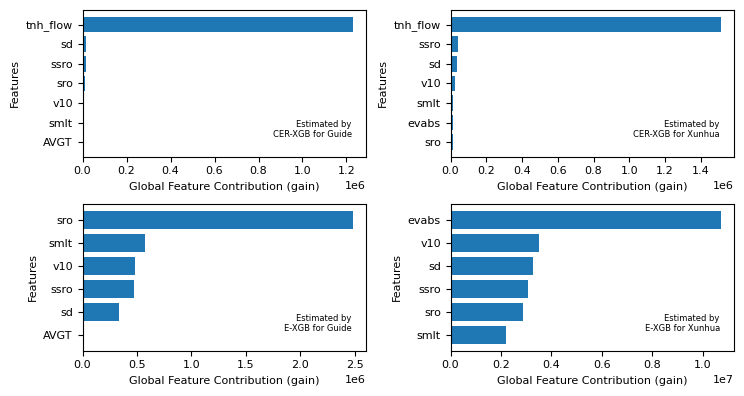

In [61]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from OneShotSamplesGenerator import gen_one_out_samples
from MultiOutXGBRegressor import load_model as load_xgb_model

hydro_stations = [
    'Guide',
    'Xunhua'
]

# Create figure with 2x2 subplots
plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(2, 2, figsize=(7.48, 4))

for col, hydro_station in enumerate(hydro_stations):
    # Get CER-XGBoost global importance
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    df = df.rename(columns={'AVG-TEM(C)': 'AVGT'})
    samples,target,features = gen_one_out_samples(df,target_column='flow',mode='simulate',lags_dict=None,lag=12,lead=1)
    
    # Load trained CER-XGBoost model
    model = load_xgb_model(f'../models/CER/{hydro_station.lower()}/XGBOOST_lag12/vif_xgb_model.json')

    # Group features by base name (without lag)
    feature_groups = {}
    for feature in features:
        # Split by last underscore to handle features with multiple underscores
        base_name = '_'.join(feature.split('_')[:-1])  # Get base name before last lag
        if base_name not in feature_groups:
            feature_groups[base_name] = []
        feature_groups[base_name].append(feature)

    print(feature_groups)

    # Get global feature importance
    global_importance = model.get_score(importance_type='gain')
    global_contributions = {}
    
    # Calculate aggregated importance for feature groups
    for base_name, feature_list in feature_groups.items():
        global_contributions[base_name] = sum(global_importance.get(f, 0) for f in feature_list)

    # Plot CER-XGBoost global importance
    features_list = list(feature_groups.keys())
    global_importance_df = pd.DataFrame({
        'Predictors': features_list,
        'Importance': [global_contributions[f] for f in features_list]
    })
    
    # Sort features by importance and store the order
    global_importance_df = global_importance_df.sort_values('Importance', ascending=True)
    feature_order = global_importance_df['Predictors'].tolist()

    axes[0,col].barh(global_importance_df['Predictors'], global_importance_df['Importance'])
    axes[0,col].set_xlabel('Global Feature Contribution (gain)')
    axes[0,col].set_ylabel('Features')  # Added ylabel for first subplot
    # Add title inside the plot
    axes[0,col].text(0.95, 0.25, f'Estimated by\nCER-XGB for {hydro_station}',
                    transform=axes[0,col].transAxes, ha='right', va='top', fontsize=6,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # Get XGBoost global importance
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    df = df.rename(columns={'AVG-TEM(C)': 'AVGT'})
    df = df.drop(columns=['tnh_flow'])
    samples,target,features = gen_one_out_samples(df,target_column='flow',mode='simulate',lags_dict=None,lag=12,lead=1)
    
    # Get E-XGBoost global importance
    model = load_xgb_model(f'../models/Extension/{hydro_station.lower()}/XGBOOST_lag12/vif_xgb_model.json')
    
    feature_groups = {}
    for feature in features:
        # Split by last underscore to handle features with multiple underscores
        base_name = '_'.join(feature.split('_')[:-1])  # Get base name before last lag
        if base_name not in feature_groups:
            feature_groups[base_name] = []
        feature_groups[base_name].append(feature)

    # Get global feature importance
    global_importance = model.get_score(importance_type='gain')
    global_contributions = {}
    
    # Calculate aggregated importance for feature groups
    for base_name, feature_list in feature_groups.items():
        global_contributions[base_name] = sum(global_importance.get(f, 0) for f in feature_list)

    # Plot CER-XGBoost global importance
    features_list = list(feature_groups.keys())
    global_importance_df = pd.DataFrame({
        'Predictors': features_list,
        'Importance': [global_contributions[f] for f in features_list]
    })
    
    # Sort features by importance and store the order
    global_importance_df = global_importance_df.sort_values('Importance', ascending=True)
    feature_order = global_importance_df['Predictors'].tolist()
    
    axes[1,col].barh(global_importance_df['Predictors'], global_importance_df['Importance'])
    axes[1,col].set_xlabel('Global Feature Contribution (gain)')
    axes[1,col].set_ylabel('Features')
    # Add title inside the plot
    axes[1,col].text(0.95, 0.25, f'Estimated by\nE-XGB for {hydro_station}',
                    transform=axes[1,col].transAxes, ha='right', va='top', fontsize=6,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

fig.tight_layout()
plt.savefig('../figs/global_feature_importance_comparison.tif', format='TIFF', dpi=500, bbox_inches='tight')
plt.savefig('../figs/global_feature_importance_comparison.png', format='PNG', dpi=600, bbox_inches='tight')
plt.show()


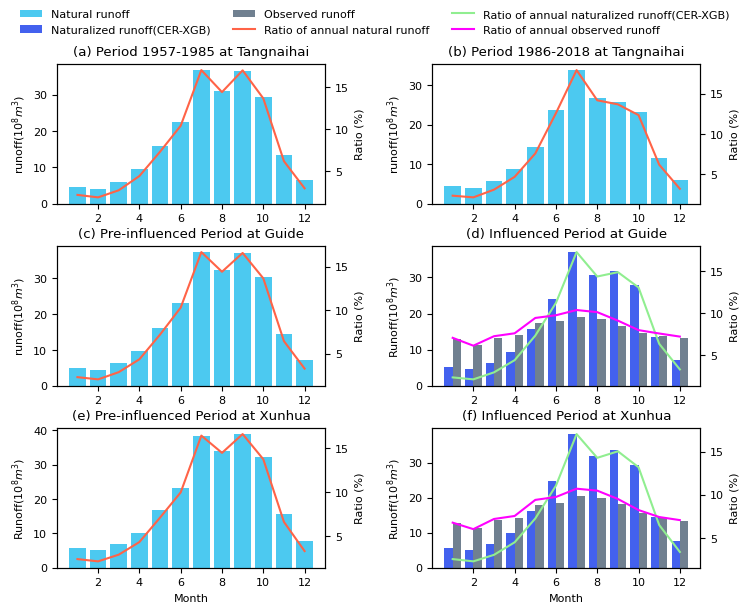

In [55]:
import pandas as pd
import calendar
import matplotlib.pyplot as plt

def Get_days_from_month(date):
    year = date.year
    month = date.month
    # year, month, day = map(int, date.split('-'))

    # 获取该月的天数
    days_in_month = calendar.monthrange(year, month)[1]

    return days_in_month

# 唐乃亥影响前期天然径流
tnh_preinfl = pd.read_csv('../data/tangnaihai_monthly_flow.csv', parse_dates=['date'],index_col='date').sort_index()
tnh_preinfl = tnh_preinfl.loc['1957-01-01':'1985-12-01']
tnh_preinfl['date_'] = tnh_preinfl.index
tnh_preinfl['days'] = tnh_preinfl['date_'].apply(Get_days_from_month)
tnh_preinfl['runoff(10^8m^3)'] = tnh_preinfl['flow(m^3/s)']*tnh_preinfl['days']*24*3600/100000000
tnh_preinfl['month'] = tnh_preinfl['date_'].dt.month
tnh_preinfl = tnh_preinfl.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
tnh_preinfl.set_index('month',inplace=True)
tnh_preinfl['Ratio'] = tnh_preinfl/tnh_preinfl.sum()*100

# 唐乃亥影响期实测径流
tnh_infl_obs = pd.read_csv('../data/tangnaihai_monthly_flow.csv', parse_dates=['date'],index_col='date').sort_index()
tnh_infl_obs = tnh_infl_obs.loc['1986-01-01':'2018-12-01']
tnh_infl_obs['date_'] = tnh_infl_obs.index
tnh_infl_obs['days'] = tnh_infl_obs['date_'].apply(Get_days_from_month)
tnh_infl_obs['runoff(10^8m^3)'] = tnh_infl_obs['flow(m^3/s)']*tnh_infl_obs['days']*24*3600/100000000
tnh_infl_obs['month'] = tnh_infl_obs['date_'].dt.month
tnh_infl_obs = tnh_infl_obs.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
tnh_infl_obs.set_index('month',inplace=True)
tnh_infl_obs['Ratio'] = tnh_infl_obs/tnh_infl_obs.sum()*100



# 贵德影响期天然径流:CER-XGB
guide_infl_cer_xgb = pd.read_csv('../results/vif_xgb_guide.csv', parse_dates=['date'],index_col='date').sort_index()
guide_infl_cer_xgb['date_'] = guide_infl_cer_xgb.index
guide_infl_cer_xgb['days'] = guide_infl_cer_xgb['date_'].apply(Get_days_from_month)
guide_infl_cer_xgb['runoff(10^8m^3)'] = guide_infl_cer_xgb['CER-XGB']*guide_infl_cer_xgb['days']*24*3600/100000000
guide_infl_cer_xgb['month'] = guide_infl_cer_xgb['date_'].dt.month
guide_infl_cer_xgb = guide_infl_cer_xgb.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
guide_infl_cer_xgb.set_index('month',inplace=True)
guide_infl_cer_xgb['Ratio'] = guide_infl_cer_xgb/guide_infl_cer_xgb.sum()*100

guide_infl_cer_lstm = pd.read_csv('../results/vif_lstm_guide.csv', parse_dates=['date'],index_col='date').sort_index()
guide_infl_cer_lstm['date_'] = guide_infl_cer_lstm.index
guide_infl_cer_lstm['days'] = guide_infl_cer_lstm['date_'].apply(Get_days_from_month)
guide_infl_cer_lstm['runoff(10^8m^3)'] = guide_infl_cer_lstm['CER-LSTM']*guide_infl_cer_lstm['days']*24*3600/100000000
guide_infl_cer_lstm['month'] = guide_infl_cer_lstm['date_'].dt.month
guide_infl_cer_lstm = guide_infl_cer_lstm.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
guide_infl_cer_lstm.set_index('month',inplace=True)
guide_infl_cer_lstm['Ratio'] = guide_infl_cer_lstm/guide_infl_cer_lstm.sum()*100

guide_infl_cer_bilstm = pd.read_csv('../results/vif_bilstm_guide.csv', parse_dates=['date'],index_col='date').sort_index()
guide_infl_cer_bilstm['date_'] = guide_infl_cer_bilstm.index
guide_infl_cer_bilstm['days'] = guide_infl_cer_bilstm['date_'].apply(Get_days_from_month)
guide_infl_cer_bilstm['runoff(10^8m^3)'] = guide_infl_cer_bilstm['CER-BiLSTM']*guide_infl_cer_bilstm['days']*24*3600/100000000
guide_infl_cer_bilstm['month'] = guide_infl_cer_bilstm['date_'].dt.month
guide_infl_cer_bilstm = guide_infl_cer_bilstm.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
guide_infl_cer_bilstm.set_index('month',inplace=True)
guide_infl_cer_bilstm['Ratio'] = guide_infl_cer_bilstm/guide_infl_cer_bilstm.sum()*100

guide_infl_cer_mlr = pd.read_csv('../results/vif_mlr_guide.csv', parse_dates=['date'],index_col='date').sort_index()
guide_infl_cer_mlr['date_'] = guide_infl_cer_mlr.index
guide_infl_cer_mlr['days'] = guide_infl_cer_mlr['date_'].apply(Get_days_from_month)
guide_infl_cer_mlr['runoff(10^8m^3)'] = guide_infl_cer_mlr['CER-MLR']*guide_infl_cer_mlr['days']*24*3600/100000000
guide_infl_cer_mlr['month'] = guide_infl_cer_mlr['date_'].dt.month
guide_infl_cer_mlr = guide_infl_cer_mlr.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
guide_infl_cer_mlr.set_index('month',inplace=True)
guide_infl_cer_mlr['Ratio'] = guide_infl_cer_mlr/guide_infl_cer_mlr.sum()*100

# 贵德影响期实测径流
guide_infl_obs = pd.read_csv('../data/guide_monthly_flow.csv', parse_dates=['date'],index_col='date').sort_index()
guide_infl_obs = guide_infl_obs.loc['1986-01-01':'2018-12-01']
guide_infl_obs['date_'] = guide_infl_obs.index
guide_infl_obs['days'] = guide_infl_obs['date_'].apply(Get_days_from_month)
guide_infl_obs['runoff(10^8m^3)'] = guide_infl_obs['flow(m^3/s)']*guide_infl_obs['days']*24*3600/100000000
guide_infl_obs['month'] = guide_infl_obs['date_'].dt.month
guide_infl_obs = guide_infl_obs.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
guide_infl_obs.set_index('month',inplace=True)
guide_infl_obs['Ratio'] = guide_infl_obs/guide_infl_obs.sum()*100

# 贵德影响前期径流
guide_preinfl = pd.read_csv('../data/guide_monthly_flow.csv', parse_dates=['date'],index_col='date').sort_index()
# select rows where date column range from 1957-01-01 to 1985-12-01
guide_preinfl = guide_preinfl.loc['1957-01-01':'1985-12-01']
guide_preinfl['date_'] = guide_preinfl.index
guide_preinfl['days'] = guide_preinfl['date_'].apply(Get_days_from_month)
guide_preinfl['runoff(10^8m^3)'] = guide_preinfl['flow(m^3/s)']*guide_preinfl['days']*24*3600/100000000
guide_preinfl['month'] = guide_preinfl['date_'].dt.month
guide_preinfl = guide_preinfl.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
guide_preinfl.set_index('month',inplace=True)
guide_preinfl['Ratio'] = guide_preinfl/guide_preinfl.sum()*100


# 循化影响期天然径流
xunhua_infl_cer_xgb = pd.read_csv('../results/vif_xgb_xunhua.csv', parse_dates=['date'],index_col='date').sort_index()
xunhua_infl_cer_xgb['date_'] = xunhua_infl_cer_xgb.index
xunhua_infl_cer_xgb['days'] = xunhua_infl_cer_xgb['date_'].apply(Get_days_from_month)
xunhua_infl_cer_xgb['runoff(10^8m^3)'] = xunhua_infl_cer_xgb['CER-XGB']*xunhua_infl_cer_xgb['days']*24*3600/100000000
xunhua_infl_cer_xgb['month'] = xunhua_infl_cer_xgb['date_'].dt.month
xunhua_infl_cer_xgb = xunhua_infl_cer_xgb.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
xunhua_infl_cer_xgb.set_index('month',inplace=True)
xunhua_infl_cer_xgb['Ratio'] = xunhua_infl_cer_xgb/xunhua_infl_cer_xgb.sum()*100

xunhua_infl_cer_lstm = pd.read_csv('../results/vif_lstm_xunhua.csv', parse_dates=['date'],index_col='date').sort_index()
xunhua_infl_cer_lstm['date_'] = xunhua_infl_cer_lstm.index
xunhua_infl_cer_lstm['days'] = xunhua_infl_cer_lstm['date_'].apply(Get_days_from_month)
xunhua_infl_cer_lstm['runoff(10^8m^3)'] = xunhua_infl_cer_lstm['CER-LSTM']*xunhua_infl_cer_lstm['days']*24*3600/100000000
xunhua_infl_cer_lstm['month'] = xunhua_infl_cer_lstm['date_'].dt.month
xunhua_infl_cer_lstm = xunhua_infl_cer_lstm.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
xunhua_infl_cer_lstm.set_index('month',inplace=True)
xunhua_infl_cer_lstm['Ratio'] = xunhua_infl_cer_lstm/xunhua_infl_cer_lstm.sum()*100

xunhua_infl_cer_bilstm = pd.read_csv('../results/vif_bilstm_xunhua.csv', parse_dates=['date'],index_col='date').sort_index()
xunhua_infl_cer_bilstm['date_'] = xunhua_infl_cer_bilstm.index
xunhua_infl_cer_bilstm['days'] = xunhua_infl_cer_bilstm['date_'].apply(Get_days_from_month)
xunhua_infl_cer_bilstm['runoff(10^8m^3)'] = xunhua_infl_cer_bilstm['CER-BiLSTM']*xunhua_infl_cer_bilstm['days']*24*3600/100000000
xunhua_infl_cer_bilstm['month'] = xunhua_infl_cer_bilstm['date_'].dt.month
xunhua_infl_cer_bilstm = xunhua_infl_cer_bilstm.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
xunhua_infl_cer_bilstm.set_index('month',inplace=True)
xunhua_infl_cer_bilstm['Ratio'] = xunhua_infl_cer_bilstm/xunhua_infl_cer_bilstm.sum()*100

xunhua_infl_cer_mlr = pd.read_csv('../results/vif_mlr_xunhua.csv', parse_dates=['date'],index_col='date').sort_index()
xunhua_infl_cer_mlr['date_'] = xunhua_infl_cer_mlr.index
xunhua_infl_cer_mlr['days'] = xunhua_infl_cer_mlr['date_'].apply(Get_days_from_month)
xunhua_infl_cer_mlr['runoff(10^8m^3)'] = xunhua_infl_cer_mlr['CER-MLR']*xunhua_infl_cer_mlr['days']*24*3600/100000000
xunhua_infl_cer_mlr['month'] = xunhua_infl_cer_mlr['date_'].dt.month
xunhua_infl_cer_mlr = xunhua_infl_cer_mlr.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
xunhua_infl_cer_mlr.set_index('month',inplace=True)
xunhua_infl_cer_mlr['Ratio'] = xunhua_infl_cer_mlr/xunhua_infl_cer_mlr.sum()*100

# 循化影响期实测径流
xunhua_infl_obs = pd.read_csv('../data/xunhua_monthly_flow.csv', parse_dates=['date'],index_col='date').sort_index()
xunhua_infl_obs = xunhua_infl_obs.loc['1986-01-01':'2018-12-01']
xunhua_infl_obs['date_'] = xunhua_infl_obs.index
xunhua_infl_obs['days'] = xunhua_infl_obs['date_'].apply(Get_days_from_month)
xunhua_infl_obs['runoff(10^8m^3)'] = xunhua_infl_obs['flow(m^3/s)']*xunhua_infl_obs['days']*24*3600/100000000
xunhua_infl_obs['month'] = xunhua_infl_obs['date_'].dt.month
xunhua_infl_obs = xunhua_infl_obs.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
xunhua_infl_obs.set_index('month',inplace=True)
xunhua_infl_obs['Ratio'] = xunhua_infl_obs/xunhua_infl_obs.sum()*100

# 循化影响前期径流
xunhua_preinfl = pd.read_csv('../data/xunhua_monthly_flow.csv', parse_dates=['date'],index_col='date').sort_index()
# select rows where date column range from 1957-01-01 to 1985-12-01
xunhua_preinfl = xunhua_preinfl.loc['1957-01-01':'1985-12-01']
xunhua_preinfl['date_'] = xunhua_preinfl.index
xunhua_preinfl['days'] = xunhua_preinfl['date_'].apply(Get_days_from_month)
xunhua_preinfl['runoff(10^8m^3)'] = xunhua_preinfl['flow(m^3/s)']*xunhua_preinfl['days']*24*3600/100000000
xunhua_preinfl['month'] = xunhua_preinfl['date_'].dt.month
xunhua_preinfl = xunhua_preinfl.groupby('month')['runoff(10^8m^3)'].mean().reset_index()
xunhua_preinfl.set_index('month',inplace=True)
xunhua_preinfl['Ratio'] = xunhua_preinfl/xunhua_preinfl.sum()*100



natural_runoff_color = '#4CC9F0' #'skyblue'
ratio_natural_runoff_color = 'tomato'

naturalized_runoff_color = '#4361EE'
rario_naturalized_runoff_color = 'lightgreen'
observed_runoff_color = 'slategray'
ratio_observed_runoff_color = 'fuchsia'


# set fontsize
plt.rcParams.update({'font.size': 8})
# 创建一个绘图区域，包含两个子图
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(7.48, 6.00))


# 创建第一个子图
axes[0][0].bar(tnh_preinfl.index, tnh_preinfl['runoff(10^8m^3)'], color=natural_runoff_color)
# axes[0][0].set_xlabel('Month', fontsize=ftsize)
axes[0][0].set_ylabel('runoff($10^8m^3$)')
axes[0][0].set_title('(a) Period 1957-1985 at Tangnaihai')

# 创建第二个y轴
ax2_1 = axes[0][0].twinx()
ax2_1.plot(tnh_preinfl.index, tnh_preinfl['Ratio'], color=ratio_natural_runoff_color)
ax2_1.set_ylabel('Ratio (%)')

# 子图2：影响期
axes[0][1].bar(tnh_infl_obs.index, tnh_infl_obs['runoff(10^8m^3)'], color=natural_runoff_color)
# axes[0][1].set_xlabel('Month', fontsize=ftsize)
axes[0][1].set_ylabel('runoff($10^8m^3$)')
axes[0][1].set_title('(b) Period 1986-2018 at Tangnaihai')

# 创建第二个y轴
ax2_2 = axes[0][1].twinx()
ax2_2.plot(tnh_infl_obs.index, tnh_infl_obs['Ratio'], color=ratio_natural_runoff_color)
ax2_2.set_ylabel('Ratio (%)')

# 子图1：标准期
axes[1][0].bar(guide_preinfl.index, guide_preinfl['runoff(10^8m^3)'], color=natural_runoff_color, label='Natural runoff')
# axes[1][0].set_xlabel('Month', fontsize=ftsize)
axes[1][0].set_ylabel('runoff($10^8m^3$)')
axes[1][0].set_title('(c) Pre-influenced Period at Guide')

# 创建第二个y轴
ax2_3 = axes[1][0].twinx()
ax2_3.plot(guide_preinfl.index, guide_preinfl['Ratio'], color=ratio_natural_runoff_color, label='Ratio of annual natural runoff')
ax2_3.set_ylabel('Ratio (%)')

# 子图2：影响期
axes[1][1].bar(guide_infl_cer_xgb.index - 0.2, guide_infl_cer_xgb['runoff(10^8m^3)'], width=0.4, color=naturalized_runoff_color, label='Naturalized runoff(CER-XGB)')
axes[1][1].bar(guide_infl_obs.index + 0.2, guide_infl_obs['runoff(10^8m^3)'], width=0.4, color=observed_runoff_color, label='Observed runoff')
# axes[1][1].set_xlabel('Month', fontsize=ftsize)
axes[1][1].set_ylabel('Runoff($10^8m^3$)')
axes[1][1].set_title('(d) Influenced Period at Guide')

# 创建第二个y轴
ax2_4 = axes[1][1].twinx()
ax2_4.plot(guide_infl_cer_xgb.index, guide_infl_cer_xgb['Ratio'], color=rario_naturalized_runoff_color, label='Ratio of annual naturalized runoff(CER-XGB)')
ax2_4.plot(guide_infl_obs.index, guide_infl_obs['Ratio'], color=ratio_observed_runoff_color, label='Ratio of annual observed runoff')
ax2_4.set_ylabel('Ratio (%)')

# 子图3：循化影响前期径流
axes[2][0].bar(xunhua_preinfl.index, xunhua_preinfl['runoff(10^8m^3)'], color=natural_runoff_color)
axes[2][0].set_xlabel('Month')
axes[2][0].set_ylabel('Runoff($10^8m^3$)')
axes[2][0].set_title('(e) Pre-influenced Period at Xunhua')

# 创建第二个y轴
ax2_5 = axes[2][0].twinx()
ax2_5.plot(xunhua_preinfl.index, xunhua_preinfl['Ratio'], color=ratio_natural_runoff_color)
ax2_5.set_ylabel('Ratio (%)')

# 子图4：循化影响后期径流
axes[2][1].bar(xunhua_infl_cer_xgb.index - 0.2, xunhua_infl_cer_xgb['runoff(10^8m^3)'], width=0.4, color=naturalized_runoff_color)
axes[2][1].bar(xunhua_infl_cer_xgb.index + 0.2, xunhua_infl_obs['runoff(10^8m^3)'], width=0.4, color=observed_runoff_color)
axes[2][1].set_xlabel('Month')
axes[2][1].set_ylabel('Runoff($10^8m^3$)')
axes[2][1].set_title('(f) Influenced Period at Xunhua')

# 创建第二个y轴
ax2_6 = axes[2][1].twinx()
ax2_6.plot(xunhua_infl_cer_xgb.index, xunhua_infl_cer_xgb['Ratio'], color=rario_naturalized_runoff_color)
ax2_6.plot(xunhua_infl_obs.index, xunhua_infl_obs['Ratio'], color=ratio_observed_runoff_color)
ax2_6.set_ylabel('Ratio (%)')

# 获取所有图例
handles, labels = [], []

# 获取主坐标轴的图例
for ax in axes.flat:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        handles.append(handle)
        labels.append(label)

# 获取twinx坐标轴的图例
for ax in [ax2_1, ax2_2, ax2_3, ax2_4, ax2_5, ax2_6]:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        handles.append(handle)
        labels.append(label)



fig.legend(handles, labels, 
           loc='upper center', 
        #    bbox_to_anchor=(0.5, 1.0), 
           ncol=3, 
           fontsize=8, 
           frameon=False)

# 美化
# plt.tight_layout()
plt.subplots_adjust(left=0.07, bottom=0.06, right=0.93,top=0.90, hspace=0.3, wspace=0.4)
plt.savefig('../figs/runoff_distribution.tif',format='TIFF',dpi=500,bbox_inches='tight')
plt.savefig('../figs/runoff_distribution.png',format='PNG',dpi=600,bbox_inches='tight')

plt.show()